In [ ]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

In [ ]:
## Import the dataset
from google.colab import files
import io

# Upload file manually
uploaded = files.upload()

# Read it using the filename
filename = list(uploaded.keys())[0]  # automatically gets the uploaded filename
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Now you can inspect
df.info()
df.describe(include='all')

Saving Data for coursework.csv to Data for coursework (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5708,5681,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
unique,NaN,NaN,NaN,NaN,2,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,DebtCon,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,3928,2388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.199497,18607.969799,73760.817200,101776.048741,NaN,NaN,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,NaN,NaN,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,NaN,NaN,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,NaN,NaN,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,NaN,NaN,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum().rename_axis('variable').reset_index(name='missing_count')

,variable,missing_count
0,BAD,0
1,LOAN,0
2,MORTDUE,518
3,VALUE,112
4,REASON,252
5,JOB,279
6,YOJ,515
7,DEROG,708
8,DELINQ,580
9,CLAGE,308


In [ ]:
for col in df.columns:
    print(f"Value counts for column: {col}")
    print(df[col].value_counts())
    print("-" * 40)

Value counts for column: BAD
BAD
0    4771
1    1189
Name: count, dtype: int64
----------------------------------------
Value counts for column: LOAN
LOAN
15000    105
10000     81
20000     74
25000     73
12000     69
        ... 
1100       1
89000      1
89200      1
89800      1
89900      1
Name: count, Length: 540, dtype: int64
----------------------------------------
Value counts for column: MORTDUE
MORTDUE
42000.0     11
47000.0     10
65000.0      9
55000.0      7
70000.0      7
            ..
69195.0      1
70069.0      1
155478.0     1
44817.0      1
22270.0      1
Name: count, Length: 5053, dtype: int64
----------------------------------------
Value counts for column: VALUE
VALUE
60000.0     15
80000.0     14
85000.0     12
65000.0     11
78000.0     10
            ..
70095.0      1
53149.0      1
72430.0      1
106450.0     1
64764.0      1
Name: count, Length: 5381, dtype: int64
----------------------------------------
Value counts for column: REASON
REASON
DebtCon    39

In [ ]:
## Exploratory Data Analysis (EDA)
# Basic Info
print("Dataset Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe(include='all'))

# Check for missing values
print("\nMissing Value")
df.isna().sum()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB
None

Summary Statistics
                BAD          LOAN        MORTDUE          VALUE   REASON  \
count   5960.000000   5960.000000    5442.000000    5848.000000     5708   
unique          NaN           NaN            NaN            NaN      

,0
BAD,0
LOAN,0
MORTDUE,518
VALUE,112
REASON,252
JOB,279
YOJ,515
DEROG,708
DELINQ,580
CLAGE,308


In [ ]:
# Count missing values per row
df['missing_count'] = df.isnull().sum(axis=1)

# Show rows with most missing data
df.sort_values('missing_count', ascending=False)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,missing_count
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11
1405,0,10800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11
51,0,3100,NaN,70400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
333,0,6100,NaN,47400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
112,0,4400,NaN,60250.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2516,0,14900,36120.0,57095.0,DebtCon,ProfExe,4.0,0.0,0.0,239.023675,1.0,35.0,38.171624,0
2518,0,15000,80988.0,97404.0,DebtCon,ProfExe,10.0,3.0,0.0,188.501672,1.0,30.0,26.568270,0
2519,0,15000,81483.0,134347.0,DebtCon,ProfExe,14.0,0.0,0.0,305.915076,0.0,18.0,29.653563,0
2488,0,14900,65303.0,84590.0,DebtCon,Office,6.0,0.0,0.0,121.064954,1.0,19.0,22.576824,0


# Data Preprocessing

Below is the detail of missing value for each variable:
BAD                 0
LOAN                0
MORTDUE           518
VALUE             112
REASON            252
JOB               279
YOJ               515
DEROG             708
DELINQ            580
CLAGE             308
NINQ              510
CLNO              222
DEBTINC          1267
missing_count       0
dtype: int64
Proportion of Total Missing Value: 6.317114093959732

Proportion of Missing Value for each variable: 
BAD               0.000000
LOAN              0.000000
MORTDUE           8.691275
VALUE             1.879195
REASON            4.228188
JOB               4.681208
YOJ               8.640940
DEROG            11.879195
DELINQ            9.731544
CLAGE             5.167785
NINQ              8.557047
CLNO              3.724832
DEBTINC          21.258389
missing_count     0.000000
dtype: float64


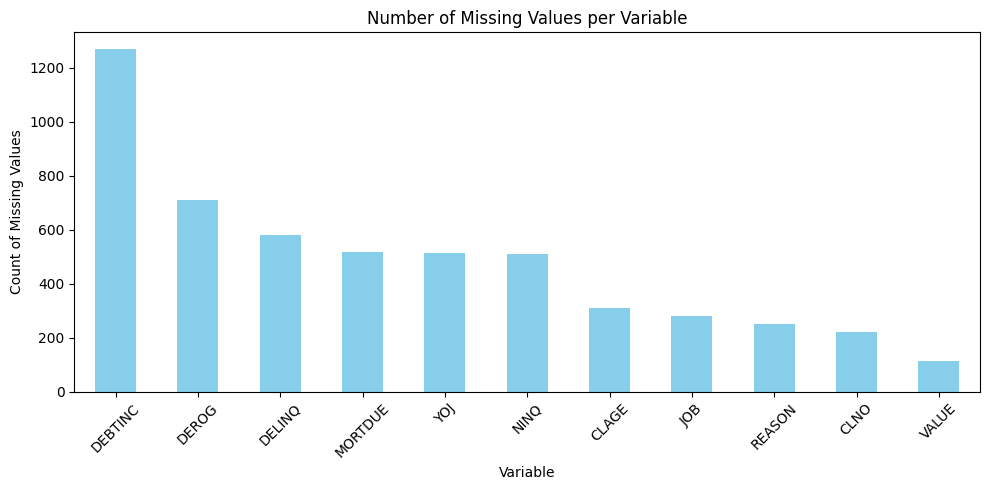

In [ ]:
## Check the missing value from original dataset before we do any preprocessing

# Check the detail of each variable
total_missing = df.isna().sum()
print("Below is the detail of missing value for each variable:\n" + str(total_missing))

# Check the missing value proportion of each variable
total_proportion = df.isna().sum().sum() / (df.shape[0] * df.shape[1])*100
proportion = df.isna().sum()/len(df)*100
print("Proportion of Total Missing Value: " + str(total_proportion))
print("\nProportion of Missing Value for each variable: \n"+ str(proportion))

total_missing = total_missing[total_missing > 0]  # Exclude columns with 0 missing

# Plot as a bar chart for each variables
plt.figure(figsize=(10, 5))
total_missing.sort_values(ascending=False).plot(kind='bar', color='skyblue')

plt.title("Number of Missing Values per Variable")
plt.ylabel("Count of Missing Values")
plt.xlabel("Variable")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## Building Assumptions: Change the Missing Value based on Assumptions made

df_filtered = df.copy()

#1 Missing Value in REASON means "Not Provided"
# Change Missing Value in Reason to Not Provided
df_filtered["REASON"] = df_filtered["REASON"].fillna("Not Provided")

#2 Missing Value in JOB categorized as "Not Provided"
# Change Missing Value in Job to Other
df_filtered["JOB"] = df_filtered["JOB"].fillna("Not Provided")

In [ ]:
## Drop the top 5% of rows with the most missing values across variables

# Add missing count column
df['missing_count'] = df.isnull().sum(axis=1)
df_filtered['missing_count'] = df_filtered.isnull().sum(axis=1)

# Calculate 95th percentile threshold
threshold = df_filtered['missing_count'].quantile(0.95)

# Keep rows below or equal to the threshold
df_filtered = df_filtered[df_filtered['missing_count'] <= threshold].copy()

# Check the detail and proportion after rows removal
total_missing = df_filtered.isna().sum()
print("Below is the detail of missing value for each variable:\n" + str(total_missing))

total_proportion = df_filtered.isna().sum().sum() / (df_filtered.shape[0] * df_filtered.shape[1])*100
proportion = df_filtered.isna().sum()/len(df_filtered)*100
print("Proportion of Total Missing Value: " + str(total_proportion))
print("\nProportion of Missing Value for each variable: \n"+ str(proportion))

Below is the detail of missing value for each variable:
BAD                 0
LOAN                0
MORTDUE           387
VALUE              90
REASON              0
JOB                 0
YOJ               353
DEROG             437
DELINQ            309
CLAGE              86
NINQ              241
CLNO                0
DEBTINC          1199
missing_count       0
dtype: int64
Proportion of Total Missing Value: 3.8954189270644966

Proportion of Missing Value for each variable: 
BAD               0.000000
LOAN              0.000000
MORTDUE           6.803797
VALUE             1.582278
REASON            0.000000
JOB               0.000000
YOJ               6.206048
DEROG             7.682841
DELINQ            5.432489
CLAGE             1.511955
NINQ              4.236990
CLNO              0.000000
DEBTINC          21.079466
missing_count     0.000000
dtype: float64


In [ ]:
# Count frequency of missing values per row
original_grouped = df['missing_count'].value_counts().sort_index()
filtered_grouped = df_filtered['missing_count'].value_counts().sort_index()

# Combine into one table
comparison_table = pd.DataFrame({
    'Missing_Variables': original_grouped.index,
    'Original_Count': original_grouped.values,
    'Filtered_Count': filtered_grouped.reindex(original_grouped.index, fill_value=0).values
})

# Add total row at the bottom
total_row = pd.DataFrame({
    'Missing_Variables': ['Total'],
    'Original_Count': [comparison_table['Original_Count'].sum()],
    'Filtered_Count': [comparison_table['Filtered_Count'].sum()]
})

comparison_table = pd.concat([comparison_table, total_row], ignore_index=True)

# Display the table
print(comparison_table)

# Identify removed rows
removed_rows = df[df['missing_count'] > threshold].copy()

# Compare shape
print("\nOriginal data:", df.shape)
print("Filtered data:", df_filtered.shape)
print("Removed rows:", removed_rows.shape)

# See where most missing occurs in removed rows
removed_missing_summary = removed_rows.isnull().sum().sort_values(ascending=False)
print("\nTop missing columns in removed rows:")
print(removed_missing_summary[removed_missing_summary > 0])

# Drop helper column
df_filtered.drop(columns='missing_count', inplace=True)

   Missing_Variables  Original_Count  Filtered_Count
0                  0            3364            3515
1                  1            1589            1507
2                  2             449             439
3                  3             219             191
4                  4              64              36
5                  5              83               0
6                  6              66               0
7                  7              25               0
8                  8              39               0
9                  9              49               0
10                10              11               0
11                11               2               0
12             Total            5960            5688

Original data: (5960, 14)
Filtered data: (5688, 14)
Removed rows: (275, 14)

Top missing columns in removed rows:
DELINQ     272
DEROG      271
NINQ       270
CLAGE      224
CLNO       222
YOJ        163
JOB        134
MORTDUE    133
REASON      88
DEBTINC 

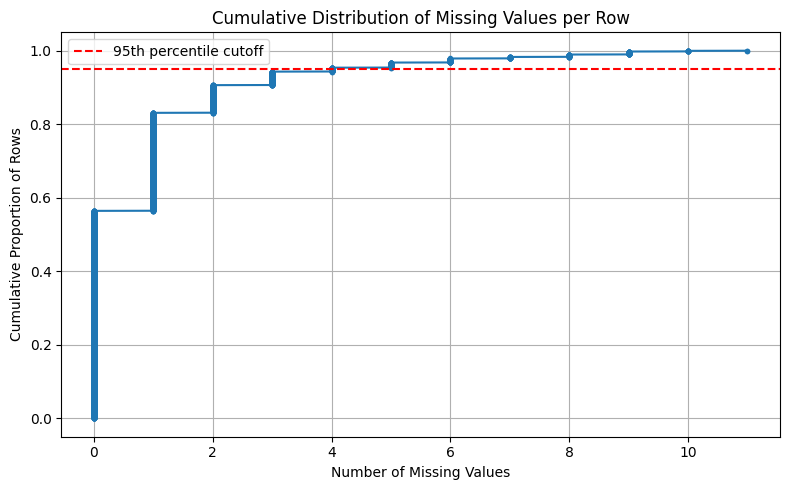

In [ ]:
## Cumulative Distribution Visualization for 5% Removal

sorted_counts = np.sort(df['missing_count'])
cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)

plt.figure(figsize=(8, 5))
plt.plot(sorted_counts, cdf, marker='.')
plt.axhline(0.95, color='red', linestyle='--', label='95th percentile cutoff')
plt.title("Cumulative Distribution of Missing Values per Row")
plt.xlabel("Number of Missing Values")
plt.ylabel("Cumulative Proportion of Rows")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Drop helper column
df.drop(columns='missing_count', inplace=True)

In [ ]:
# List of variables to check
vars_to_check = ['MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']

# Set the difference threshold (e.g., 10%)
threshold_diff = 0.10

# Store variables meeting the criteria
strong_difference_flags = []

# Analyze each variable
for var in vars_to_check:
    missing_df = df_filtered[df_filtered[var].isnull()]
    not_missing_df = df_filtered[df_filtered[var].notnull()]

    # Calculate default rates
    missing_default = missing_df['BAD'].mean() if not missing_df.empty else None
    not_missing_default = not_missing_df['BAD'].mean() if not missing_df.empty else None

    # Skip if one of the groups is empty
    if missing_default is None or not_missing_default is None:
        continue

    # Calculate difference
    diff = abs(missing_default - not_missing_default)

    print(f"{var}: Missing = {missing_default:.2%}, Not Missing = {not_missing_default:.2%}, Diff = {diff:.2%}")

    if diff > threshold_diff:
        strong_difference_flags.append(var)

print("\nVariables with default rate difference > {:.0%}:".format(threshold_diff))
print(strong_difference_flags)

# Create Flagging Column
for col in strong_difference_flags:
    df_filtered[f'{col}_missing'] = df_filtered[col].isnull().astype(int)

MORTDUE: Missing = 20.16%, Not Missing = 19.88%, Diff = 0.27%
VALUE: Missing = 100.00%, Not Missing = 18.61%, Diff = 81.39%
YOJ: Missing = 15.01%, Not Missing = 20.22%, Diff = 5.21%
DEROG: Missing = 6.86%, Not Missing = 20.99%, Diff = 14.12%
DELINQ: Missing = 5.18%, Not Missing = 20.75%, Diff = 15.57%
CLAGE: Missing = 29.07%, Not Missing = 19.76%, Diff = 9.31%
NINQ: Missing = 8.71%, Not Missing = 20.40%, Diff = 11.68%
DEBTINC: Missing = 61.88%, Not Missing = 8.69%, Diff = 53.20%

Variables with default rate difference > 10%:
['VALUE', 'DEROG', 'DELINQ', 'NINQ', 'DEBTINC']


In [ ]:
# Impute Missing Data in Columns MORTDUE, VALUE, YOJ, CLAGE, CLNO, DEBTINC with Median
cols_to_fill = ['MORTDUE', 'VALUE', 'YOJ', 'CLAGE', 'CLNO', 'DEBTINC']

for col in cols_to_fill:
    df_filtered[col] = df_filtered[col].fillna(df_filtered[col].median())

#Impute Missing Data in Columns DEROG, DELINQ, NINQ with Zero
cols_to_fill = ['DEROG', 'DELINQ', 'NINQ']

for col in cols_to_fill:
    df_filtered[col] = df_filtered[col].fillna(0)

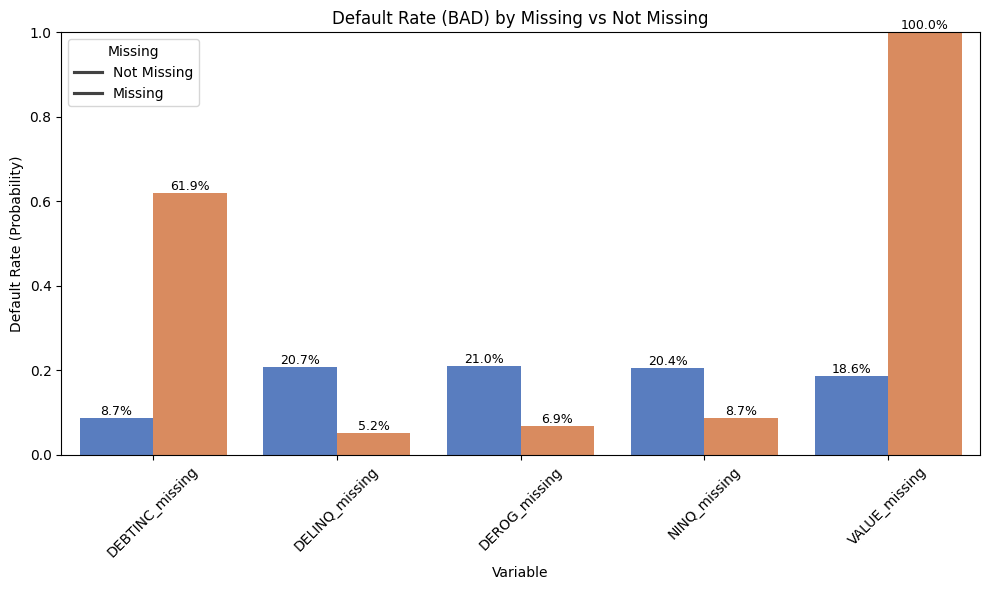

In [ ]:
# List of missing flag columns you created
missing_flags = ['VALUE_missing', 'DEROG_missing', 'DELINQ_missing', 'NINQ_missing', 'DEBTINC_missing']


# Step 1: Prepare long-form data for seaborn
df_plot = df_filtered[['BAD'] + missing_flags].copy()

df_melted = df_plot.melt(id_vars='BAD', value_vars=missing_flags,
                         var_name='Missing_Flag', value_name='Is_Missing')

# Step 2: Group and calculate default rate for missing vs not missing
summary = df_melted.groupby(['Missing_Flag', 'Is_Missing'])['BAD'].mean().reset_index()

# Step 3: Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=summary, x='Missing_Flag', y='BAD', hue='Is_Missing', palette='muted')

# Optional: Add % labels on top of bars
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v * 100:.1f}%' for v in container.datavalues], fontsize=9)

plt.title("Default Rate (BAD) by Missing vs Not Missing")
plt.ylabel("Default Rate (Probability)")
plt.xlabel("Variable")
plt.legend(title="Missing", labels=["Not Missing", "Missing"])
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## Outlier Handling

# Vars where only the upper end should be capped
upper_only = ['DEROG', 'DELINQ', 'NINQ']

# Vars where both ends can be capped
both_ends = ['CLNO', 'DEBTINC']

# Apply upper-only capping
for var in upper_only:
    upper = df_filtered[var].quantile(0.995)
    df_filtered[var] = np.where(df_filtered[var] > upper, upper, df_filtered[var])

# Apply full windsorizing for others
for var in both_ends:
    lower = df_filtered[var].quantile(0.005)
    upper = df_filtered[var].quantile(0.995)
    df_filtered[var] = np.clip(df_filtered[var], lower, upper)

# Apply upper cap removal for CLAGE
upper_limit = df_filtered['CLAGE'].quantile(0.99975)

# Remove rows with outliers
df_filtered = df_filtered[df_filtered['CLAGE'] <= upper_limit]

In [ ]:
# Apply one-hot encoding to Categorical columns
df_encoded = pd.get_dummies(df_filtered, columns=['REASON', 'JOB'], prefix=['REASON', 'JOB'],dtype=int)

# Display the encoded DataFrame
df_encoded.head()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,REASON_DebtCon,REASON_HomeImp,REASON_Not Provided,JOB_Mgr,JOB_Not Provided,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,...,0,1,0,0,0,0,1,0,0,0
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,...,0,1,0,0,0,0,1,0,0,0
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,...,0,1,0,0,0,0,1,0,0,0
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,...,0,1,0,0,0,1,0,0,0,0
5,1,1700,30548.0,40320.0,9.0,0.0,0.0,101.466002,1.0,8.0,...,0,1,0,0,0,0,1,0,0,0


In [ ]:
## Feature Scaling

#Excluding the target variable "Bad"
numeric_cols = df_encoded.select_dtypes(include=['float64', 'int64']).columns.drop('BAD')

#Apply minmax scaler for each numerical (exclude Encoded Columns)
scaler = preprocessing.MinMaxScaler()
df_scaled = scaler.fit_transform(df_encoded[numeric_cols])

# Convert scaled result back to a DataFrame
df_scaled_numeric = pd.DataFrame(df_scaled, columns=numeric_cols,index=df_encoded.index)

# Combine scaled numeric columns with encoded columns and target column
df_others=df_encoded.drop(numeric_cols,axis=1)
df_final=pd.concat([df_others,df_scaled_numeric],axis=1)

# Check final dataset
for col in df_final.columns:
    unique_vals = df_final[col].unique()
    print(f"\n{col} — Unique values: {unique_vals[:10]}")  # Limit to first 10 values
    print(f"Total unique: {len(unique_vals)}")


BAD — Unique values: [1 0]
Total unique: 2

LOAN — Unique values: [0.         0.00225225 0.0045045  0.00675676 0.00788288 0.01013514
 0.01126126 0.01238739 0.01351351 0.01463964]
Total unique: 540

MORTDUE — Unique values: [0.05986862 0.17104962 0.02877327 0.24085568 0.07166272 0.11720132
 0.06651538 0.07707673 0.15833725 0.04670341]
Total unique: 4919

VALUE — Unique values: [0.03659001 0.07123406 0.01026054 0.12265467 0.0381173  0.05783286
 0.04131811 0.04568887 0.06398092 0.02571031]
Total unique: 5156

YOJ — Unique values: [0.25609756 0.17073171 0.09756098 0.07317073 0.2195122  0.12195122
 0.26829268 0.3902439  0.06097561 0.19512195]
Total unique: 99

DEROG — Unique values: [0.         0.5        0.33333333 0.16666667 0.66666667 0.83333333
 1.        ]
Total unique: 7

DELINQ — Unique values: [0.         0.33333333 0.16666667 1.         0.66666667 0.5
 0.83333333]
Total unique: 7

CLAGE — Unique values: [0.14523599 0.18750885 0.23003822 0.14364563 0.1561623  0.11866155
 0.13661628

In [ ]:
df_final

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,REASON_DebtCon,REASON_HomeImp,REASON_Not Provided,JOB_Mgr,JOB_Not Provided,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1,0.000000,0.059869,0.036590,0.256098,0.0,0.000000,0.145236,0.1,0.163636,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1,0.002252,0.171050,0.071234,0.170732,0.0,0.333333,0.187509,0.0,0.254545,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,0.004505,0.028773,0.010261,0.097561,0.0,0.000000,0.230038,0.1,0.181818,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0,0.006757,0.240856,0.122655,0.073171,0.0,0.000000,0.143646,0.0,0.254545,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,1,0.006757,0.071663,0.038117,0.219512,0.0,0.000000,0.156162,0.1,0.145455,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,0.988739,0.138875,0.096927,0.390244,0.0,0.000000,0.341377,0.0,0.290909,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5956,0,0.989865,0.132112,0.100172,0.390244,0.0,0.000000,0.321190,0.0,0.272727,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5957,0,0.992117,0.130777,0.100157,0.365854,0.0,0.000000,0.326711,0.0,0.272727,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5958,0,0.998874,0.121531,0.098903,0.341463,0.0,0.000000,0.329194,0.0,0.290909,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Models without log transform

In [ ]:
## Train-test-split Model
from sklearn.model_selection import train_test_split

X = df_final.drop(columns='BAD')  # features
y = df_final['BAD']               # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Logistic Regression Model

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[2797  392]
 [ 148  643]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.91      3189
           1       0.62      0.81      0.70       791

    accuracy                           0.86      3980
   macro avg       0.79      0.84      0.81      3980
weighted avg       0.88      0.86      0.87      3980

Train ROC AUC: 0.9167

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[1167  200]
 [  71  268]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.85      0.90      1367
           1       0.57      0.79      0.66       339

    accuracy                           0.84      1706
   macro avg       0.76      0.82      0.78      1706
weighted avg       0.87      0.84      0.85      1706

Test ROC AUC: 0.8910


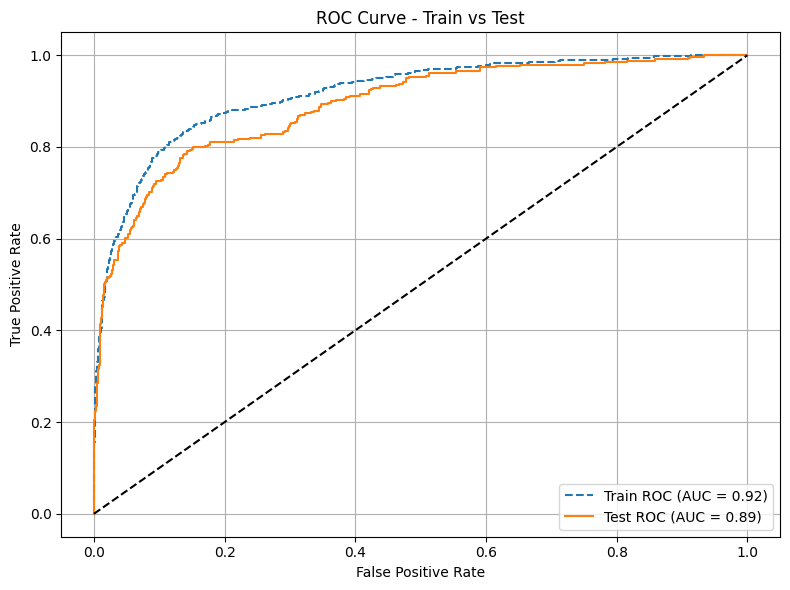

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Step 1: Train the model
model = LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=10000, random_state=42)
model.fit(X_train, y_train)

# Step 2: Predict for both train and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

# Step 3: ROC AUC for both
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Step 4: Print results

print("===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# Step 5: Plot ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.2f})', linestyle='--')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Train vs Test")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Decision Tree

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3189    0]
 [   0  791]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3189
           1       1.00      1.00      1.00       791

    accuracy                           1.00      3980
   macro avg       1.00      1.00      1.00      3980
weighted avg       1.00      1.00      1.00      3980

Train ROC AUC Score: 1.0000

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[1278   89]
 [ 111  228]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93      1367
           1       0.72      0.67      0.70       339

    accuracy                           0.88      1706
   macro avg       0.82      0.80      0.81      1706
weighted avg       0.88      0.88      0.88      1706

Test ROC AUC Score: 0.8037


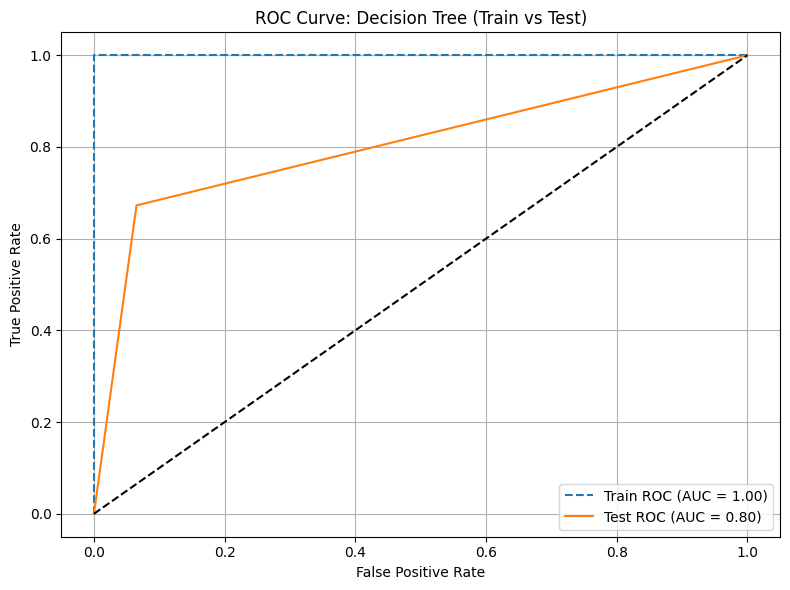

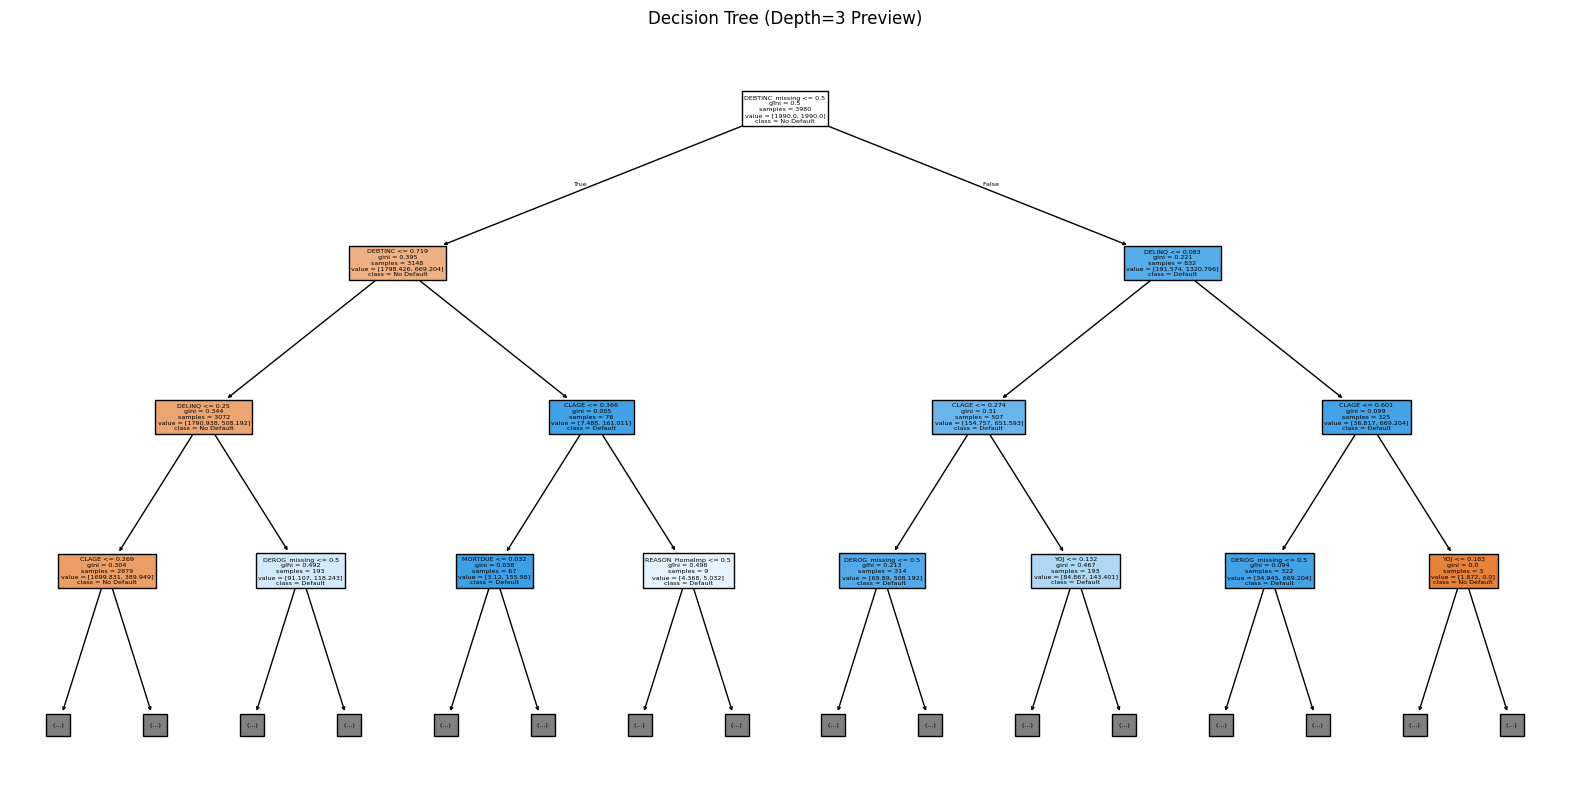

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Train the Decision Tree
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

y_train_proba_dt = dt_model.predict_proba(X_train)[:, 1]
y_test_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# 3. AUC scores
auc_train = roc_auc_score(y_train, y_train_proba_dt)
auc_test = roc_auc_score(y_test, y_test_proba_dt)

# 4. Evaluation: Train
print("===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_dt))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_dt))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 5. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_dt))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 6. ROC Curve: Train vs Test
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_dt)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.2f})", linestyle='--')
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. Visualize the Tree (Preview to depth=3)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X_train.columns, class_names=['No Default', 'Default'], max_depth=3)
plt.title("Decision Tree (Depth=3 Preview)")
plt.show()

Fitting 5 folds for each of 45 candidates, totalling 225 fits
✅ Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
✅ Best Cross-Validation AUC: 0.8741806978984921

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[2772  417]
 [ 142  649]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91      3189
           1       0.61      0.82      0.70       791

    accuracy                           0.86      3980
   macro avg       0.78      0.84      0.80      3980
weighted avg       0.88      0.86      0.87      3980

Train ROC AUC Score: 0.9048

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[1173  194]
 [  81  258]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.86      0.90      1367
           1       0.57      0.76      0.65       339

    accuracy                           0.84      1706
   macro avg       0.7

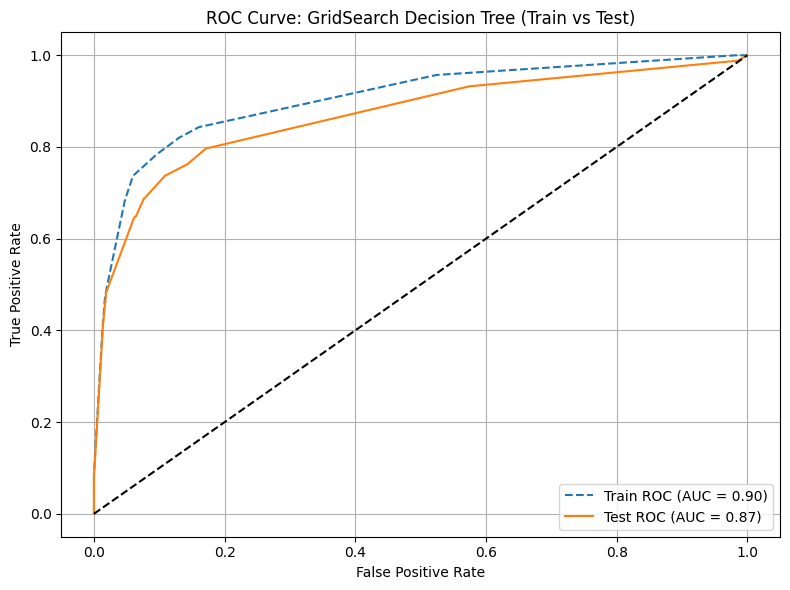

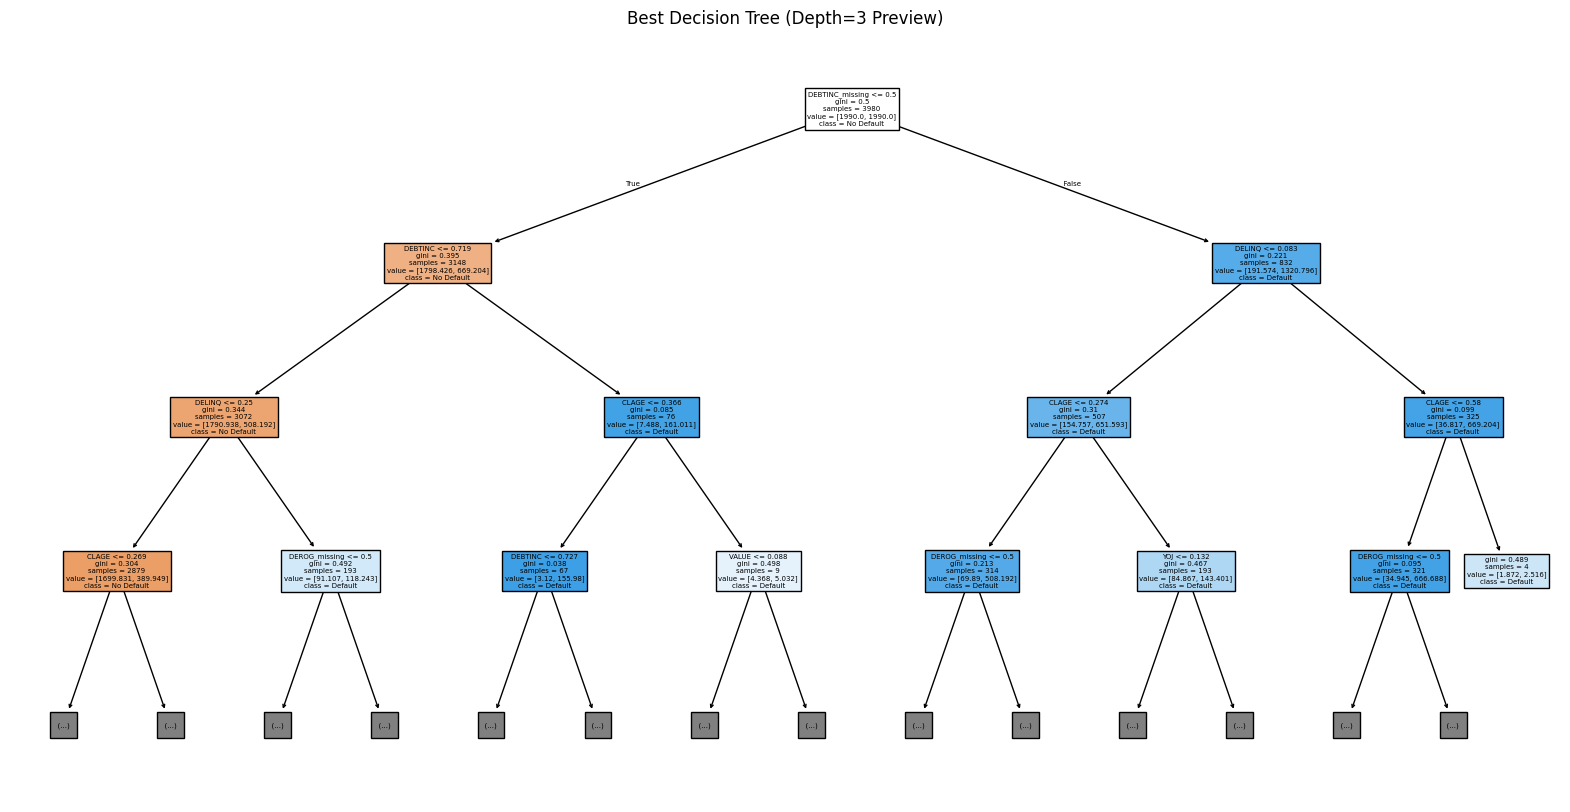

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Initialize the model
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# 3. Grid Search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("✅ Best Parameters:", grid_search.best_params_)
print("✅ Best Cross-Validation AUC:", grid_search.best_score_)

# 4. Best model from grid search
best_tree = grid_search.best_estimator_

# 5. Predictions: train & test
y_train_pred = best_tree.predict(X_train)
y_test_pred = best_tree.predict(X_test)

y_train_proba = best_tree.predict_proba(X_train)[:, 1]
y_test_proba = best_tree.predict_proba(X_test)[:, 1]

# 6. AUC scores
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 7. Train Evaluation
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 8. Test Evaluation
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 9. ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.2f})", linestyle='--')
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: GridSearch Decision Tree (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Visualize Tree (Preview to Depth=3)
plt.figure(figsize=(20, 10))
plot_tree(best_tree, filled=True, feature_names=X_train.columns, class_names=['No Default', 'Default'], max_depth=3)
plt.title("Best Decision Tree (Depth=3 Preview)")
plt.show()

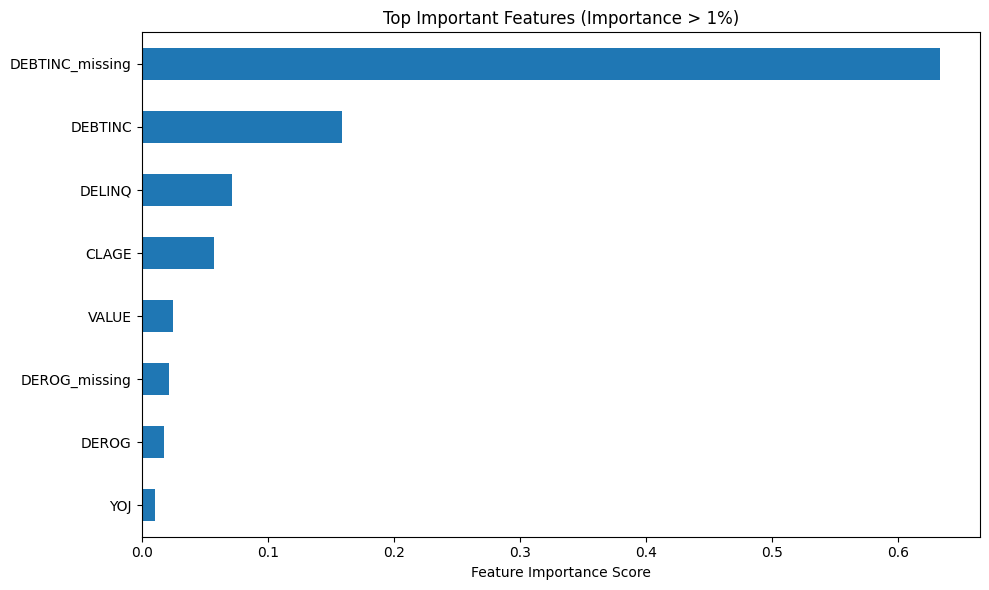

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the importance series
importance = pd.Series(best_tree.feature_importances_, index=X_train.columns)

# Filter only important features (e.g., > 1%)
important_features = importance[importance > 0.01]

# Sort and plot
important_features.sort_values().plot(
    kind='barh',
    figsize=(10, 6),
    title='Top Important Features (Importance > 1%)'
)

plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

## Random Forest


===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3189    0]
 [   0  791]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3189
           1       1.00      1.00      1.00       791

    accuracy                           1.00      3980
   macro avg       1.00      1.00      1.00      3980
weighted avg       1.00      1.00      1.00      3980

Train ROC AUC Score: 1.0000

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[1305   62]
 [ 103  236]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      1367
           1       0.79      0.70      0.74       339

    accuracy                           0.90      1706
   macro avg       0.86      0.83      0.84      1706
weighted avg       0.90      0.90      0.90      1706

Test ROC AUC Score: 0.9551


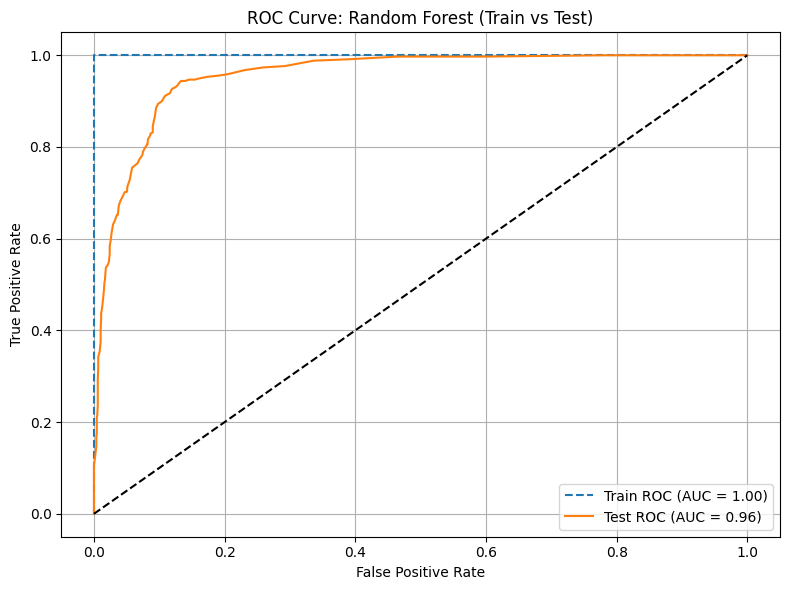

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Initialize and train the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# 2. Predictions: train and test
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 3. AUC Scores
auc_train_rf = roc_auc_score(y_train, y_train_proba_rf)
auc_test_rf = roc_auc_score(y_test, y_test_proba_rf)

# 4. Train Evaluation
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_rf))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_rf))
print(f"Train ROC AUC Score: {auc_train_rf:.4f}")

# 5. Test Evaluation
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_rf))
print(f"Test ROC AUC Score: {auc_test_rf:.4f}")

# 6. ROC Curve: Train vs Test
fpr_train_rf, tpr_train_rf, _ = roc_curve(y_train, y_train_proba_rf)
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, y_test_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train_rf, tpr_train_rf, label=f"Train ROC (AUC = {auc_train_rf:.2f})", linestyle='--')
plt.plot(fpr_test_rf, tpr_test_rf, label=f"Test ROC (AUC = {auc_test_rf:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Random Forest (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

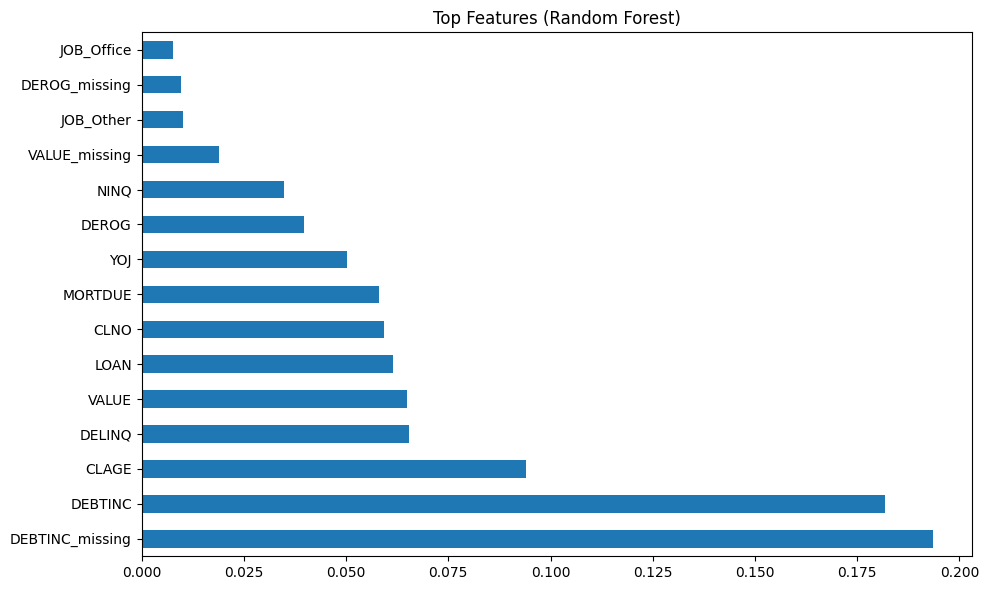

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.nlargest(15).plot(kind='barh', figsize=(10, 6), title='Top Features (Random Forest)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

train_auc_scores = []
test_auc_scores = []

fold = 1
for train_index, test_index in cv.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    rf.fit(X_train_fold, y_train_fold)

    # Predict probabilities for AUC
    y_train_proba = rf.predict_proba(X_train_fold)[:, 1]
    y_test_proba = rf.predict_proba(X_test_fold)[:, 1]

    # AUC scores
    auc_train = roc_auc_score(y_train_fold, y_train_proba)
    auc_test = roc_auc_score(y_test_fold, y_test_proba)

    train_auc_scores.append(auc_train)
    test_auc_scores.append(auc_test)

    print(f"\n=== Fold {fold} ===")
    print(f"Train AUC: {auc_train:.4f}")
    print(f"Test AUC:  {auc_test:.4f}")

    fold += 1

# Final summary
print("\nCross-Validation Summary:")
print(f"Average Train AUC: {np.mean(train_auc_scores):.4f}")
print(f"Average Test AUC:  {np.mean(test_auc_scores):.4f}")


=== Fold 1 ===
Train AUC: 1.0000
Test AUC:  0.9598

=== Fold 2 ===
Train AUC: 1.0000
Test AUC:  0.9696

=== Fold 3 ===
Train AUC: 1.0000
Test AUC:  0.9616

=== Fold 4 ===
Train AUC: 1.0000
Test AUC:  0.9670

=== Fold 5 ===
Train AUC: 1.0000
Test AUC:  0.9595

Cross-Validation Summary:
Average Train AUC: 1.0000
Average Test AUC:  0.9635


## XGBoost

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3189    0]
 [   0  791]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3189
           1       1.00      1.00      1.00       791

    accuracy                           1.00      3980
   macro avg       1.00      1.00      1.00      3980
weighted avg       1.00      1.00      1.00      3980

Train ROC AUC Score: 1.0000

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[1298   69]
 [  64  275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      1367
           1       0.80      0.81      0.81       339

    accuracy                           0.92      1706
   macro avg       0.88      0.88      0.88      1706
weighted avg       0.92      0.92      0.92      1706

Test ROC AUC Score: 0.9675


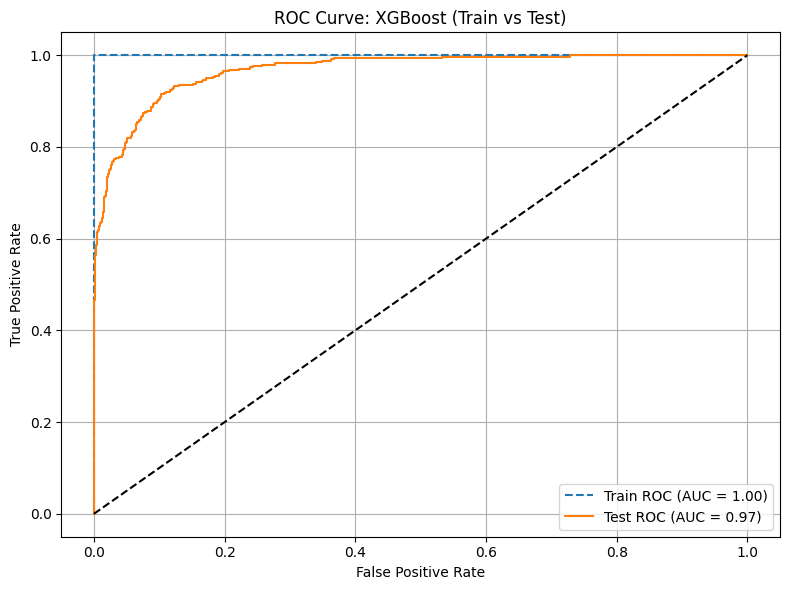

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Train the model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 2. Predictions: train & test
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

y_train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 3. AUC scores
auc_train_xgb = roc_auc_score(y_train, y_train_proba_xgb)
auc_test_xgb = roc_auc_score(y_test, y_test_proba_xgb)

# 4. Evaluation: Train
print("===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_xgb))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_xgb))
print(f"Train ROC AUC Score: {auc_train_xgb:.4f}")

# 5. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_xgb))
print(f"Test ROC AUC Score: {auc_test_xgb:.4f}")

# 6. Plot ROC Curve (Train vs Test)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_xgb)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train_xgb:.2f})", linestyle='--')
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test_xgb:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: XGBoost (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

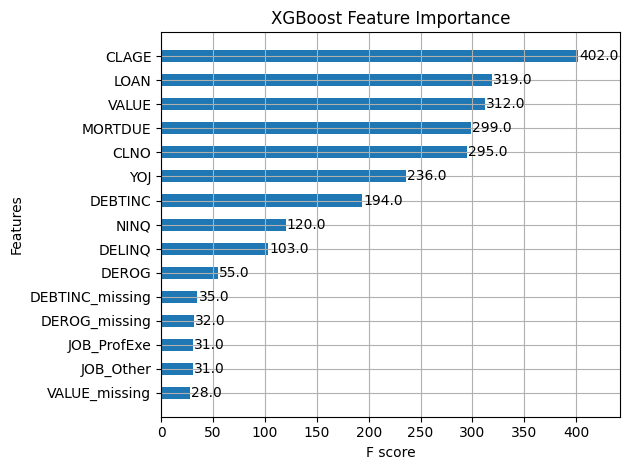

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb
xgb.plot_importance(xgb_model, max_num_features=15, height=0.5)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC: 0.919597348339757

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3113   76]
 [   2  789]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      3189
           1       0.91      1.00      0.95       791

    accuracy                           0.98      3980
   macro avg       0.96      0.99      0.97      3980
weighted avg       0.98      0.98      0.98      3980

Train ROC AUC: 0.9993

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[1277   90]
 [  61  278]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      1367
           1       0.76      0.82      0.79       339

    accuracy                           0.91      1706
   macro avg       0.85      0.88 

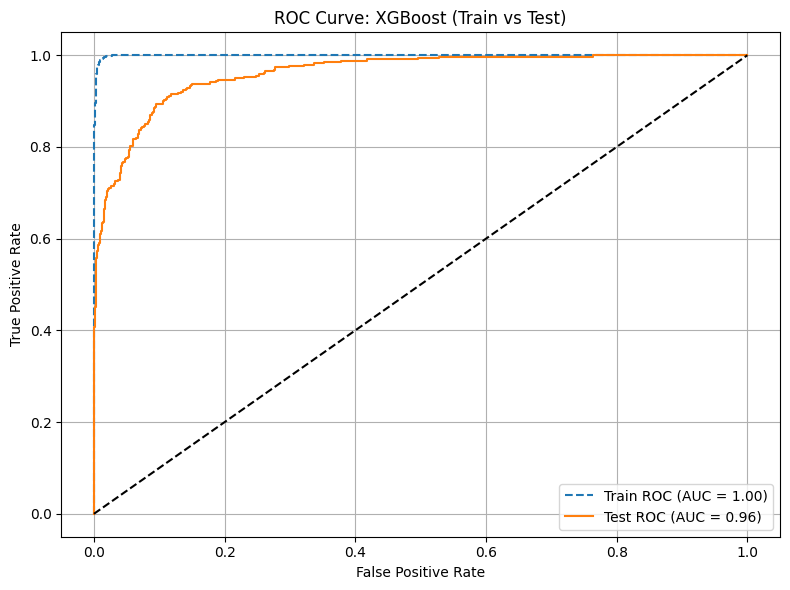

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# 1. Define parameter grid for tuning
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

# 2. Initialize base model with imbalance handling
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42
)

# 3. GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall_weighted',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 4. Best estimator
best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

# 5. Predict on train & test
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

y_train_proba = best_xgb.predict_proba(X_train)[:, 1]
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

# 6. AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 7. Train Evaluation
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

# 8. Test Evaluation
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# 9. ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.2f})", linestyle='--')
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: XGBoost (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Neural Network: MLP

Confusion Matrix:
[[1290   77]
 [  81  258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1367
           1       0.77      0.76      0.77       339

    accuracy                           0.91      1706
   macro avg       0.86      0.85      0.85      1706
weighted avg       0.91      0.91      0.91      1706


ROC AUC Score: 0.9360


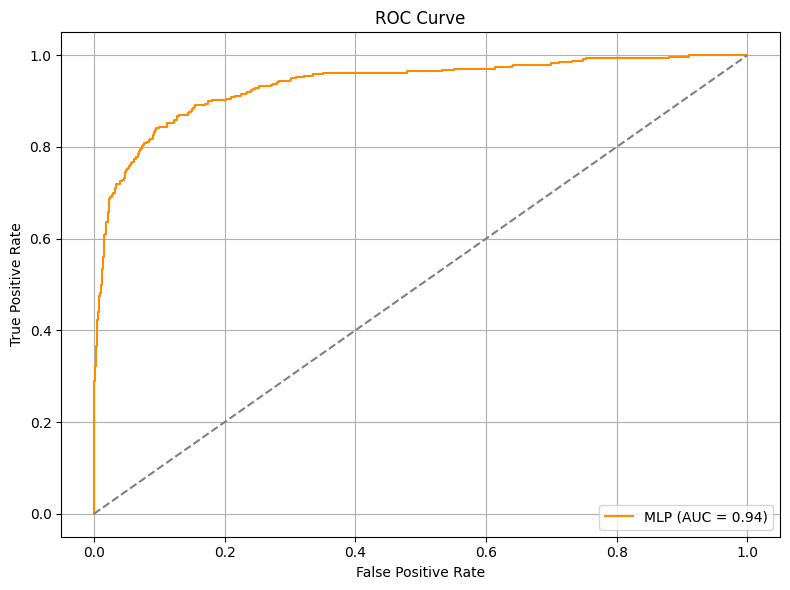

In [ ]:
from sklearn.neural_network import MLPClassifier


# Initialize the MLP model
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # You can tune this
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# Fit the model
model.fit(X_train, y_train)

# Predict labels
y_pred = model.predict(X_test)

# Predict probabilities (for ROC AUC)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC AUC Score
auc = roc_auc_score(y_test, y_proba)
print(f"\nROC AUC Score: {auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'MLP (AUC = {auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Log Transform Data and Models

In [ ]:
# Step 1: Select numeric columns
numeric_cols = df_final.select_dtypes(include=[np.number])

# Step 2: Exclude binary columns (only two unique values: 0 and 1)
non_binary_numeric_cols = [
    col for col in numeric_cols.columns
    if not set(df_final[col].dropna().unique()).issubset({0, 1})
]

# Step 3: Check skewness on non-binary numeric columns
skewed_cols = df_final[non_binary_numeric_cols].apply(lambda x: x.skew()).sort_values(ascending=False)
skewed_cols = skewed_cols[skewed_cols > 1].index.tolist()  # Adjust threshold if needed

# Step 4: Apply log1p to skewed columns only
df_final_log = df_final.copy()
df_final_log[skewed_cols] = df_final_log[skewed_cols].apply(np.log1p)

df_final_log

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,REASON_DebtCon,REASON_HomeImp,REASON_Not Provided,JOB_Mgr,JOB_Not Provided,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1,0.000000,0.058145,0.035936,0.228010,0.0,0.000000,0.145236,0.09531,0.163636,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1,0.002250,0.157900,0.068811,0.157629,0.0,0.287682,0.187509,0.00000,0.254545,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,0.004494,0.028367,0.010208,0.093090,0.0,0.000000,0.230038,0.09531,0.181818,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0,0.006734,0.215801,0.115696,0.070618,0.0,0.000000,0.143646,0.00000,0.254545,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,1,0.006734,0.069211,0.037409,0.198451,0.0,0.000000,0.156162,0.09531,0.145455,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,0.687501,0.130041,0.092512,0.329479,0.0,0.000000,0.341377,0.00000,0.290909,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5956,0,0.688067,0.124085,0.095467,0.329479,0.0,0.000000,0.321190,0.00000,0.272727,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5957,0,0.689198,0.122905,0.095453,0.311780,0.0,0.000000,0.326711,0.00000,0.272727,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5958,0,0.692584,0.114695,0.094313,0.293761,0.0,0.000000,0.329194,0.00000,0.290909,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# Assuming df_final already exists
numeric_cols = df_final.select_dtypes(include=[np.number])

# Step 1: Calculate original skewness
original_skew = numeric_cols.apply(lambda x: x.skew())

# Step 2: Identify binary columns (with only 0 and 1)
is_binary = numeric_cols.apply(lambda x: set(x.dropna().unique()).issubset({0, 1}))

# Step 3: Identify skewed columns (abs(skew) > 1) and not binary
skewed_cols = original_skew[(original_skew.abs() > 1) & (~is_binary)].index.tolist()

# Step 4: Apply log1p to those skewed columns only
df_transformed = df_final.copy()
df_transformed[skewed_cols] = df_transformed[skewed_cols].apply(np.log1p)

# Step 5: Calculate skewness after log transform
log_skew = df_transformed[skewed_cols].apply(lambda x: x.skew())

# Step 6: Combine into a comparison table
skew_comparison = pd.DataFrame({
    'Original Skewness': original_skew[skewed_cols],
    'Log-Transformed Skewness': log_skew
})

print(skew_comparison)

         Original Skewness  Log-Transformed Skewness
LOAN              2.019070                  1.441105
MORTDUE           1.913786                  1.345393
VALUE             3.095570                  2.124493
YOJ               1.055561                  0.764987
DEROG             4.709763                  3.959407
DELINQ            3.217252                  2.732976
NINQ              2.457226                  1.848424


In [ ]:
from sklearn.model_selection import train_test_split

columns_to_drop = [col for col in df_final_log.columns if "_missing" in col]

# Drop them from the feature set only
X = df_final_log.drop(columns=columns_to_drop + ['BAD'])
y = df_final_log['BAD']               # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Logistic Regression (Model After Log Transform)

Base Model

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[2840  804]
 [ 286  618]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.78      0.84      3644
           1       0.43      0.68      0.53       904

    accuracy                           0.76      4548
   macro avg       0.67      0.73      0.69      4548
weighted avg       0.81      0.76      0.78      4548

Train ROC AUC: 0.8182

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[706 206]
 [ 54 172]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.77      0.84       912
           1       0.46      0.76      0.57       226

    accuracy                           0.77      1138
   macro avg       0.69      0.77      0.71      1138
weighted avg       0.83      0.77      0.79      1138

Test ROC AUC: 0.8385


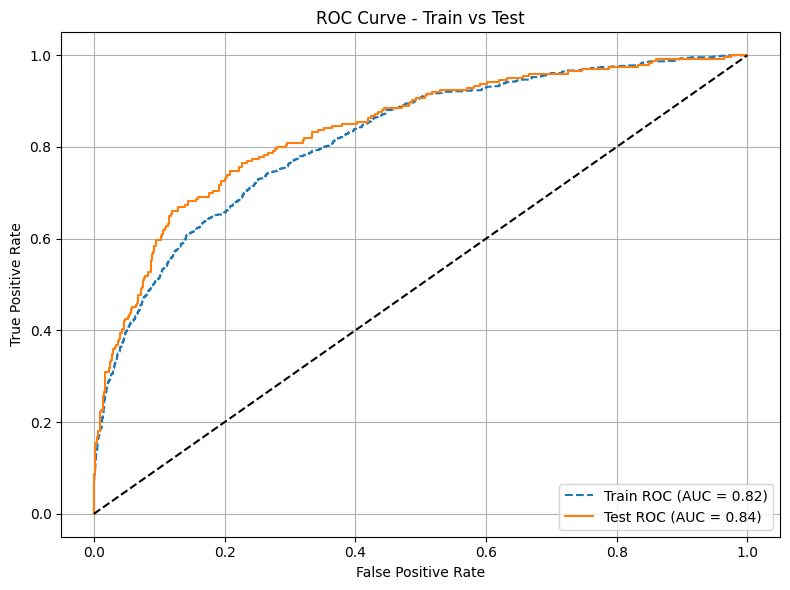

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
# Step 1: Train the model
model_logistic = LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=10000, random_state=42)
model_logistic.fit(X_train, y_train)

# Step 2: Predict for both train and test sets
y_train_pred = model_logistic.predict(X_train)
y_test_pred = model_logistic.predict(X_test)

y_train_proba = model_logistic.predict_proba(X_train)[:, 1]
y_test_proba = model_logistic.predict_proba(X_test)[:, 1]

# Step 3: ROC AUC for both
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Step 4: Print results

print("===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# Step 5: Plot ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.2f})', linestyle='--')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Train vs Test")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
#. Set up Stratified K-Fold Cross-Validation on Training Set
cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_logistic_scores=cross_val_score(model_logistic, X_train, y_train, cv=cv, scoring='recall')
print(f"Cross-Validation Recall Scores: {cv_logistic_scores}")
print(f"Mean Recall Score: {np.mean(cv_logistic_scores):.4f}")
print(f"Standard Deviation of Recall: {np.std(cv_logistic_scores):.4f}")

Cross-Validation Recall Scores: [0.65555556 0.63333333 0.71111111 0.63333333 0.62637363 0.72527473
 0.67032967 0.73626374 0.58888889 0.75555556]
Mean Recall Score: 0.6736
Standard Deviation of Recall: 0.0526


Hyperparameter Tuning

Fitting 10 folds for each of 8 candidates, totalling 80 fits

Best Parameters Found: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[2553 1091]
 [ 273  631]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.70      0.79      3644
           1       0.37      0.70      0.48       904

    accuracy                           0.70      4548
   macro avg       0.63      0.70      0.63      4548
weighted avg       0.80      0.70      0.73      4548

Train ROC AUC: 0.7747

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[623 289]
 [ 65 161]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.68      0.78       912
           1       0.36      0.71      0.48       226

    accuracy                           0.69      1138
   macro avg       0.63      0.70      0.63      1138
weight

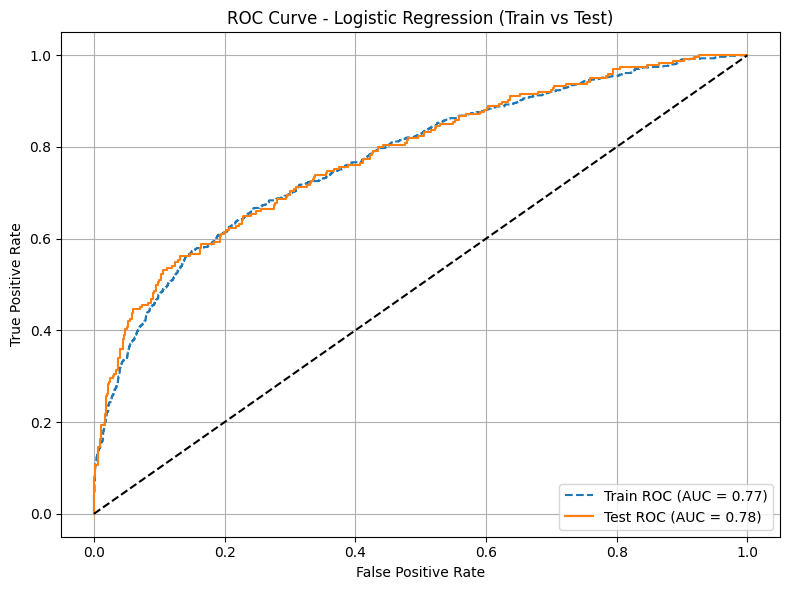

True Negatives (TN): 623
False Positives (FP): 289
False Negatives (FN): 65
True Positives (TP): 161
Expected Profit Logistic Regression: 269


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Step 1: Set up hyperparameter grid
param_grid = {
    'penalty': ['l1', 'l2'],                   # L1 = Lasso, L2 = Ridge
    'C': [0.01, 0.1, 1, 10],                   # Inverse of regularization strength
    'solver': ['liblinear'],                   # 'liblinear' supports both L1 and L2
    'class_weight': ['balanced']               # Handle class imbalance
}

# Step 2: Grid search with cross-validation
logreg_base = LogisticRegression(max_iter=10000, random_state=42)
grid_search = GridSearchCV(
    estimator=logreg_base,
    param_grid=param_grid,
    scoring='recall',
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_logreg = grid_search.best_estimator_

print("\nBest Parameters Found:", grid_search.best_params_)

# Step 3: Predict for both train and test sets
y_train_pred = best_logreg.predict(X_train)
y_test_pred = best_logreg.predict(X_test)

y_train_proba = best_logreg.predict_proba(X_train)[:, 1]
y_test_proba = best_logreg.predict_proba(X_test)[:, 1]

# Step 4: ROC AUC Scores
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Step 5: Print results
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# Step 6: Plot ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.2f})', linestyle='--')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#Expected Profit
TN_logistic, FP_logistic, FN_logistic, TP_logistic = confusion_matrix(y_test, y_test_pred).ravel()
print(f"True Negatives (TN): {TN_logistic}")
print(f"False Positives (FP): {FP_logistic}")
print(f"False Negatives (FN): {FN_logistic}")
print(f"True Positives (TP): {TP_logistic}")
exp_profit_logistic=TN_logistic-FN_logistic-FP_logistic
print(f"Expected Profit Logistic Regression: {exp_profit_logistic}")


Cross Validation after Hyperparameter (Compare Model Improvement After Hyperparameter)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
#. Set up Stratified K-Fold Cross-Validation on Training Set
cv_logistic_scores_aftercv=cross_val_score(best_logreg, X_train, y_train, cv=cv, scoring='recall')
print(f"Cross-Validation Recall Scores: {cv_logistic_scores_aftercv}")
print(f"Mean Recall Score: {np.mean(cv_logistic_scores_aftercv):.4f}")
print(f"Standard Deviation of Recall: {np.std(cv_logistic_scores_aftercv):.4f}")

Cross-Validation Recall Scores: [0.7        0.66666667 0.7        0.67777778 0.68131868 0.69230769
 0.62637363 0.71428571 0.72222222 0.73333333]
Mean Recall Score: 0.6914
Standard Deviation of Recall: 0.0292


Logistic with SMOTE


===== LOGISTIC REGRESSION + SMOTE =====

--- TRAINING SET ---
Confusion Matrix:
 [[2832  812]
 [ 274  630]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.78      0.84      3644
           1       0.44      0.70      0.54       904

    accuracy                           0.76      4548
   macro avg       0.67      0.74      0.69      4548
weighted avg       0.82      0.76      0.78      4548

Train ROC AUC: 0.8175

--- TEST SET ---
Confusion Matrix:
 [[706 206]
 [ 51 175]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.77      0.85       912
           1       0.46      0.77      0.58       226

    accuracy                           0.77      1138
   macro avg       0.70      0.77      0.71      1138
weighted avg       0.84      0.77      0.79      1138

Test ROC AUC: 0.8384


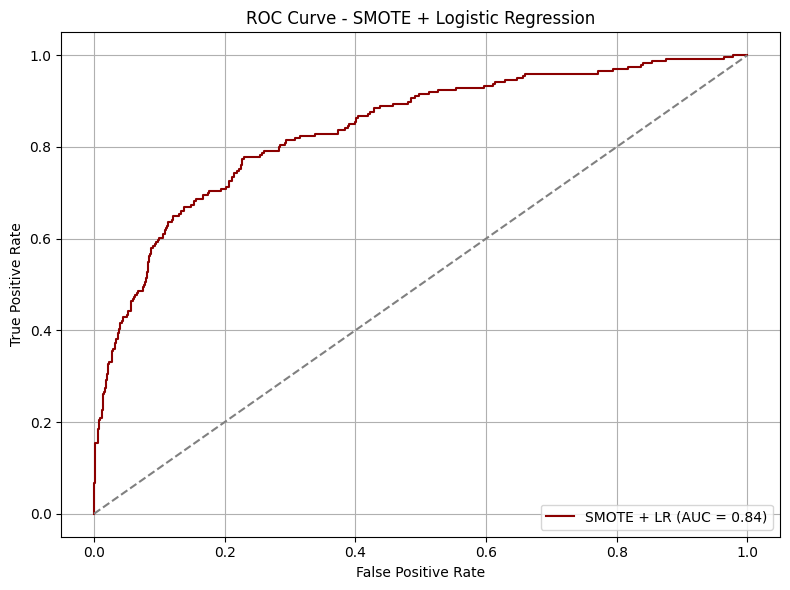


=== CLASS DISTRIBUTION AFTER SMOTE ===
BAD
0    3644
1    3644
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Step 1: Define pipeline
smote_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(solver='liblinear', max_iter=10000, random_state=42))
])

# Step 2: Fit the pipeline on training data
smote_pipeline.fit(X_train, y_train)

# Step 3: Predict
y_train_pred = smote_pipeline.predict(X_train)
y_test_pred = smote_pipeline.predict(X_test)

y_train_proba = smote_pipeline.predict_proba(X_train)[:, 1]
y_test_proba = smote_pipeline.predict_proba(X_test)[:, 1]

# Step 4: ROC AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Step 5: Evaluation
print("\n===== LOGISTIC REGRESSION + SMOTE =====")

print("\n--- TRAINING SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

print("\n--- TEST SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# Step 6: Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SMOTE + LR (AUC = {auc_test:.2f})', color='darkred')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SMOTE + Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Check if SMOTE was applied (inspect class distribution)
fitted_smote = smote_pipeline.named_steps['smote']
X_resampled, y_resampled = fitted_smote.fit_resample(X_train, y_train)

print("\n=== CLASS DISTRIBUTION AFTER SMOTE ===")
print(pd.Series(y_resampled).value_counts())

Logistic with RUS


===== LOGISTIC REGRESSION + RUS =====

--- TRAINING SET ---
Confusion Matrix:
 [[2759  885]
 [ 261  643]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.76      0.83      3644
           1       0.42      0.71      0.53       904

    accuracy                           0.75      4548
   macro avg       0.67      0.73      0.68      4548
weighted avg       0.82      0.75      0.77      4548

Train ROC AUC: 0.8129

--- TEST SET ---
Confusion Matrix:
 [[681 231]
 [ 54 172]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.75      0.83       912
           1       0.43      0.76      0.55       226

    accuracy                           0.75      1138
   macro avg       0.68      0.75      0.69      1138
weighted avg       0.83      0.75      0.77      1138

Test ROC AUC: 0.8293


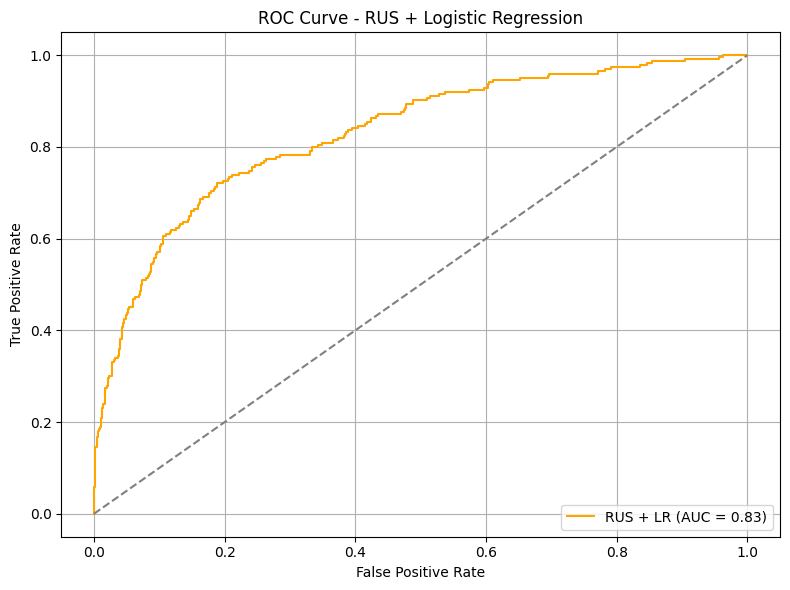


=== CLASS DISTRIBUTION AFTER RUS ===
BAD
0    904
1    904
Name: count, dtype: int64


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Step 1: Define pipeline
rus_pipeline = Pipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('lr', LogisticRegression(solver='liblinear', max_iter=10000, random_state=42))
])

# Step 2: Fit the pipeline on training data
rus_pipeline.fit(X_train, y_train)

# Step 3: Predict
y_train_pred = rus_pipeline.predict(X_train)
y_test_pred = rus_pipeline.predict(X_test)

y_train_proba = rus_pipeline.predict_proba(X_train)[:, 1]
y_test_proba = rus_pipeline.predict_proba(X_test)[:, 1]

# Step 4: ROC AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Step 5: Evaluation
print("\n===== LOGISTIC REGRESSION + RUS =====")

print("\n--- TRAINING SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

print("\n--- TEST SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# Step 6: Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'RUS + LR (AUC = {auc_test:.2f})', color='orange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RUS + Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Check if RUS was applied (inspect class distribution)
fitted_rus = rus_pipeline.named_steps['rus']
X_resampled, y_resampled = fitted_rus.fit_resample(X_train, y_train)

print("\n=== CLASS DISTRIBUTION AFTER RUS ===")
print(pd.Series(y_resampled).value_counts())


Hyperparameter Tuning + SMOTE

Fitting 5 folds for each of 8 candidates, totalling 40 fits

===== Logistic Regression + SMOTE + GridSearchCV =====
Best Parameters: {'lr__C': 0.01, 'lr__class_weight': 'balanced', 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Confusion Matrix:
 [[632 280]
 [ 64 162]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.69      0.79       912
           1       0.37      0.72      0.49       226

    accuracy                           0.70      1138
   macro avg       0.64      0.70      0.64      1138
weighted avg       0.80      0.70      0.73      1138

Test ROC AUC: 0.7986


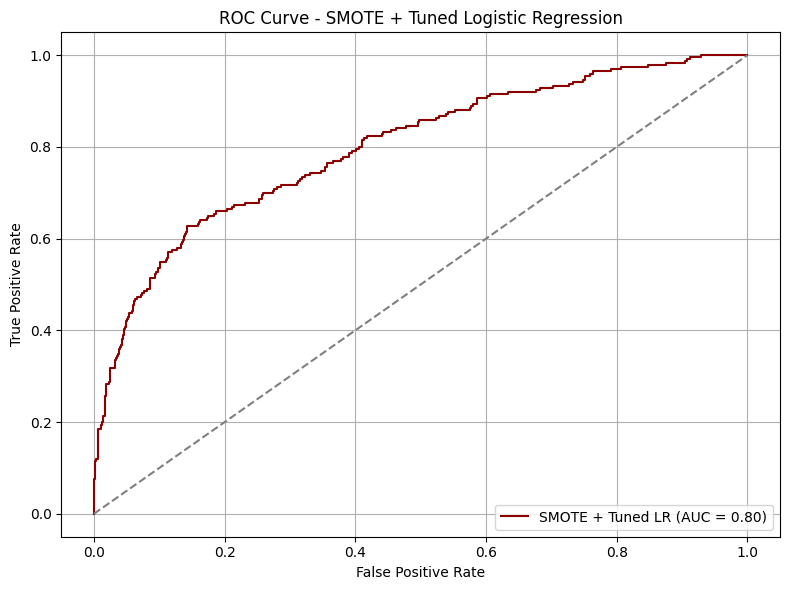


Class Distribution After SMOTE:
BAD
0    3644
1    3644
Name: count, dtype: int64


In [ ]:
# Define pipeline
smote_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(solver='liblinear', max_iter=10000, random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'lr__penalty': ['l1', 'l2'],                   # L1 = Lasso, L2 = Ridge
    'lr__C': [0.01, 0.1, 1, 10],                   # Inverse of regularization strength
    'lr__solver': ['liblinear'],                   # 'liblinear' supports both L1 and L2
    'lr__class_weight': ['balanced']               # Handle class imbalance
}

# GridSearchCV setup
grid_smote = GridSearchCV(
    smote_pipeline,
    param_grid,
    scoring='recall',  # or 'roc_auc', 'f1'
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit
grid_smote.fit(X_train, y_train)

# Best model
best_smote_model = grid_smote.best_estimator_
y_test_pred = best_smote_model.predict(X_test)
y_test_proba = best_smote_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n===== Logistic Regression + SMOTE + GridSearchCV =====")
print("Best Parameters:", grid_smote.best_params_)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SMOTE + Tuned LR (AUC = {roc_auc_score(y_test, y_test_proba):.2f})', color='darkred')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SMOTE + Tuned Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Class distribution check (optional)
X_res, y_res = best_smote_model.named_steps['smote'].fit_resample(X_train, y_train)
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_res).value_counts())

Hyperparameter Tuning + RUS

Fitting 5 folds for each of 8 candidates, totalling 40 fits

===== Logistic Regression + RUS + GridSearchCV =====
Best Parameters: {'lr__C': 0.01, 'lr__class_weight': 'balanced', 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Confusion Matrix:
 [[456 456]
 [ 60 166]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.50      0.64       912
           1       0.27      0.73      0.39       226

    accuracy                           0.55      1138
   macro avg       0.58      0.62      0.52      1138
weighted avg       0.76      0.55      0.59      1138

Test ROC AUC: 0.7279


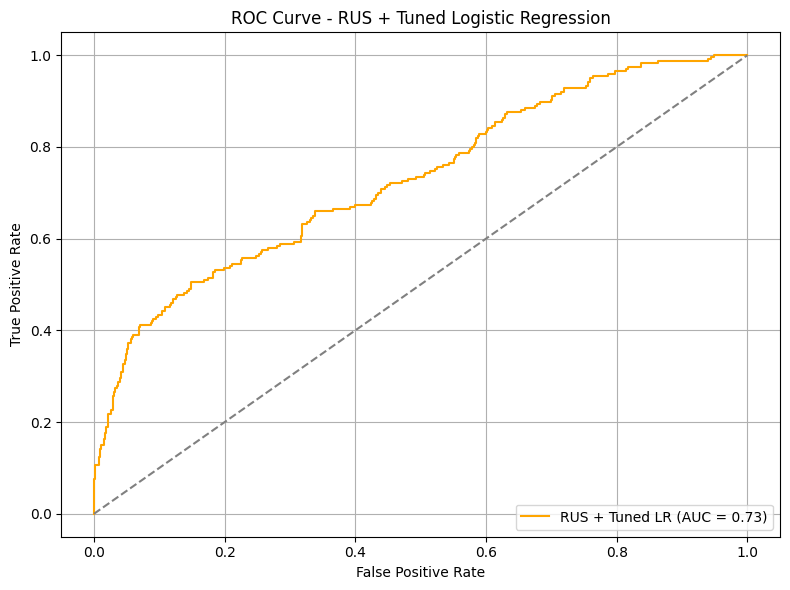


Class Distribution After RUS:
BAD
0    904
1    904
Name: count, dtype: int64


In [ ]:
# Define pipeline
rus_pipeline = Pipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('lr', LogisticRegression(solver='liblinear', max_iter=10000, random_state=42))
])

# Use same param grid
grid_rus = GridSearchCV(
    rus_pipeline,
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit
grid_rus.fit(X_train, y_train)

# Best model
best_rus_model = grid_rus.best_estimator_
y_test_pred = best_rus_model.predict(X_test)
y_test_proba = best_rus_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n===== Logistic Regression + RUS + GridSearchCV =====")
print("Best Parameters:", grid_rus.best_params_)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'RUS + Tuned LR (AUC = {roc_auc_score(y_test, y_test_proba):.2f})', color='orange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RUS + Tuned Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Class distribution check (optional)
X_res, y_res = best_rus_model.named_steps['rus'].fit_resample(X_train, y_train)
print("\nClass Distribution After RUS:")
print(pd.Series(y_res).value_counts())

## Decision Tree (Model After Log Transform)

Base Model

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3644    0]
 [   0  904]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3644
           1       1.00      1.00      1.00       904

    accuracy                           1.00      4548
   macro avg       1.00      1.00      1.00      4548
weighted avg       1.00      1.00      1.00      4548

Train ROC AUC Score: 1.0000

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[852  60]
 [ 73 153]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       912
           1       0.72      0.68      0.70       226

    accuracy                           0.88      1138
   macro avg       0.82      0.81      0.81      1138
weighted avg       0.88      0.88      0.88      1138

Test ROC AUC Score: 0.8056


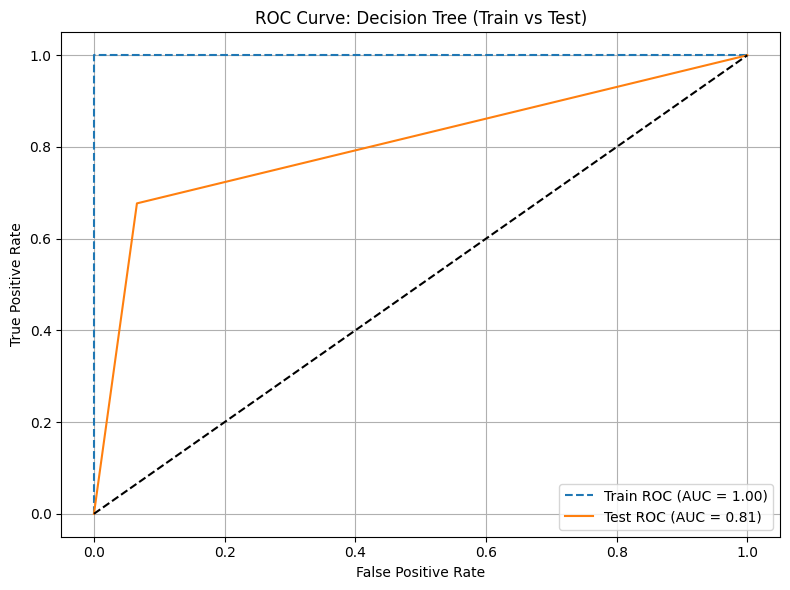

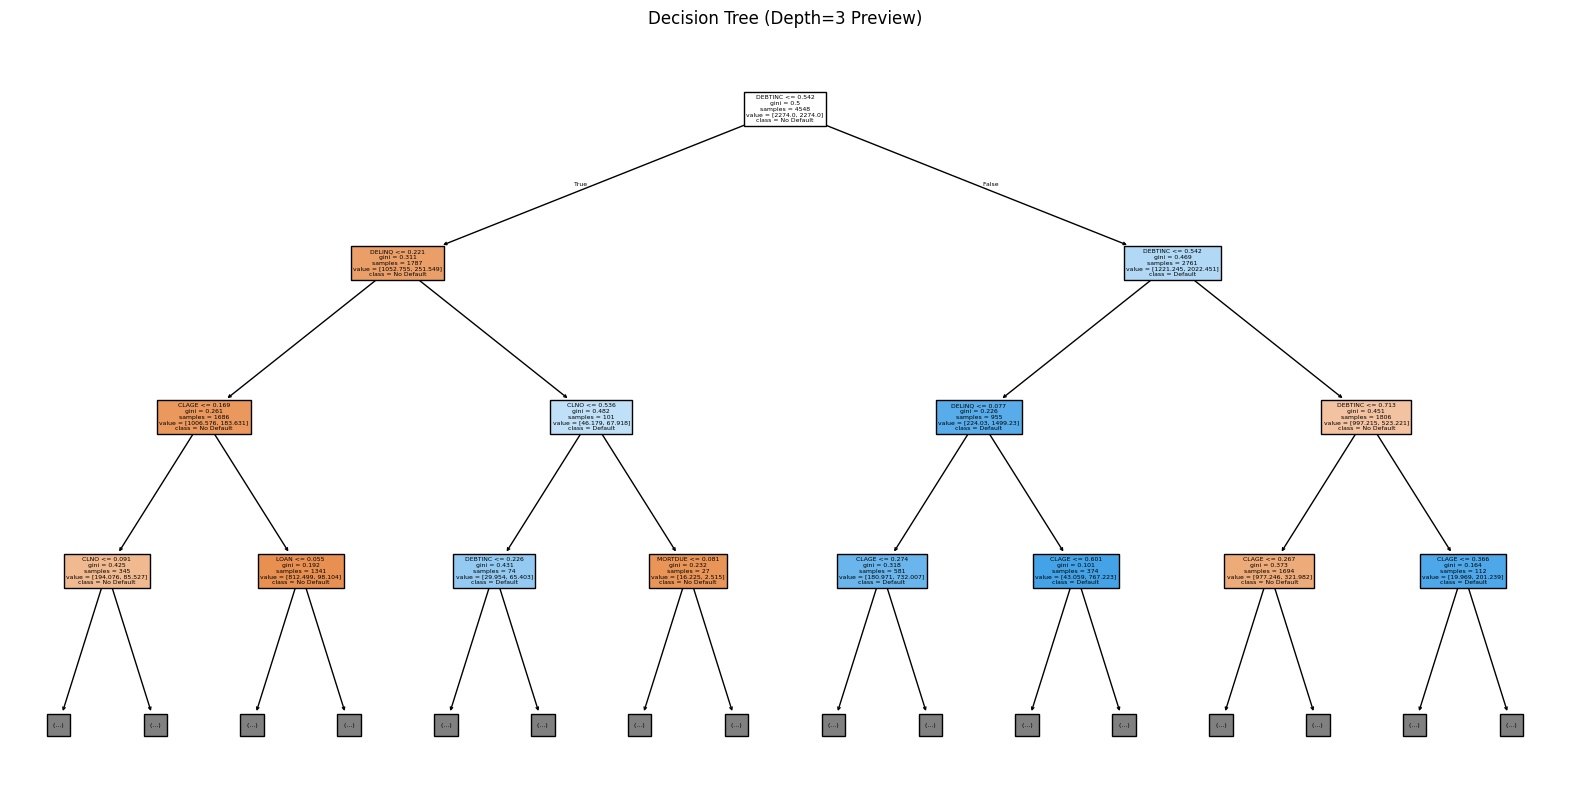

In [ ]:
# 1. Train the Decision Tree
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

y_train_proba_dt = dt_model.predict_proba(X_train)[:, 1]
y_test_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# 3. AUC scores
auc_train = roc_auc_score(y_train, y_train_proba_dt)
auc_test = roc_auc_score(y_test, y_test_proba_dt)

# 4. Evaluation: Train
print("===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_dt))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_dt))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 5. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_dt))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 6. ROC Curve: Train vs Test
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_dt)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.2f})", linestyle='--')
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. Visualize the Tree (Preview to depth=3)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X_train.columns, class_names=['No Default', 'Default'], max_depth=3)
plt.title("Decision Tree (Depth=3 Preview)")
plt.show()

Cross Validation

In [ ]:
#. Set up Stratified K-Fold Cross-Validation on Training Set
cv_dt_scores=cross_val_score(dt_model, X_train, y_train, cv=cv, scoring='recall')
print(f"Cross-Validation Recall Scores: {cv_dt_scores}")
print(f"Mean Recall Score: {np.mean(cv_dt_scores):.4f}")
print(f"Standard Deviation of Recall: {np.std(cv_dt_scores):.4f}")

Cross-Validation Recall Scores: [0.51111111 0.58888889 0.61111111 0.67777778 0.63736264 0.68131868
 0.64835165 0.59340659 0.61111111 0.62222222]
Mean Recall Score: 0.6183
Standard Deviation of Recall: 0.0468


Hyperparameter Tuning

Fitting 10 folds for each of 216 candidates, totalling 2160 fits

Best Parameters Found: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2}

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[2128 1516]
 [ 179  725]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.58      0.72      3644
           1       0.32      0.80      0.46       904

    accuracy                           0.63      4548
   macro avg       0.62      0.69      0.59      4548
weighted avg       0.80      0.63      0.66      4548

Train ROC AUC Score: 0.7500

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[503 409]
 [ 44 182]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.55      0.69       912
           1       0.31      0.81      0.45       226

    accuracy                           0.60    

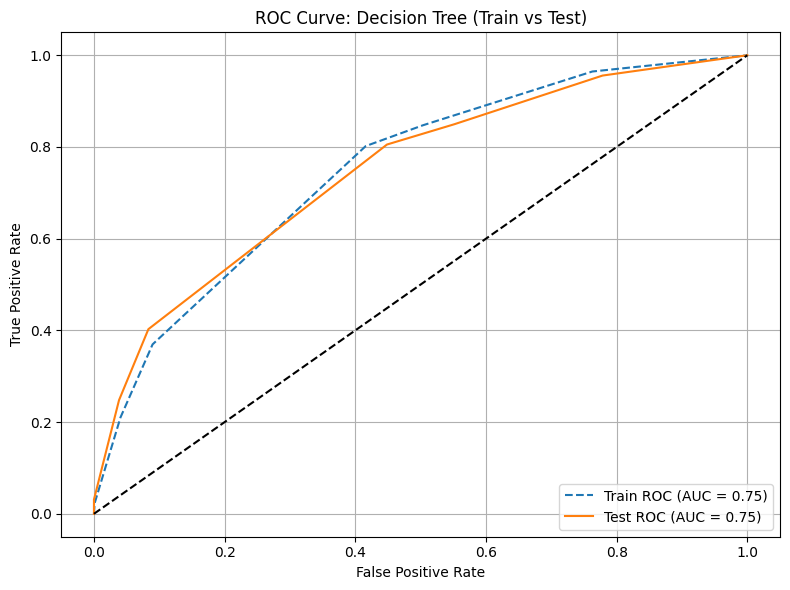

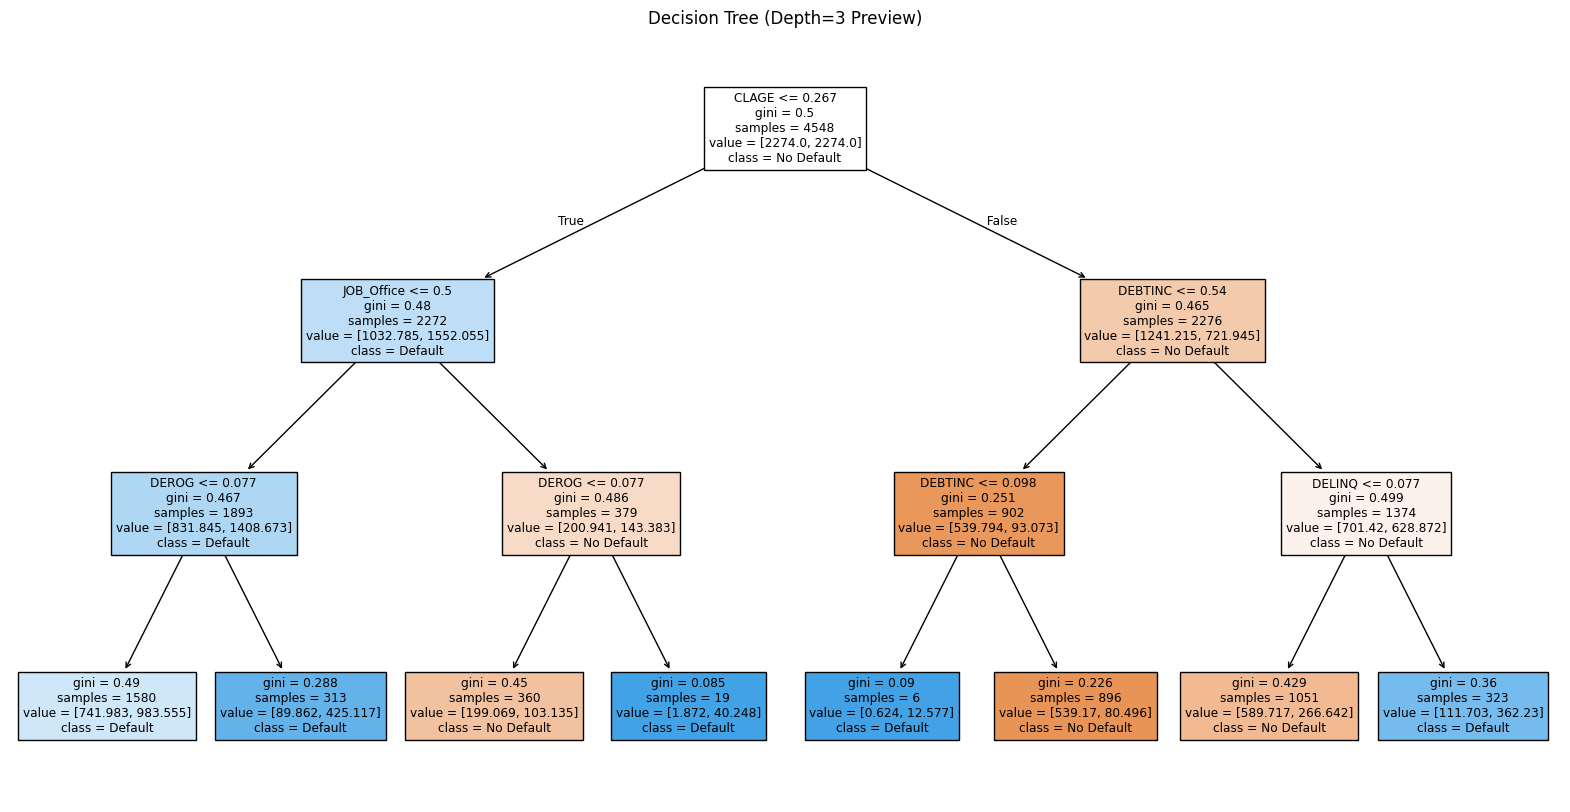

True Negatives (TN): 503
False Positives (FP): 409
False Negatives (FN): 44
True Positives (TP): 182
Expected Profit Decision Tree: 50


In [ ]:
# 1. Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

# 2. Set up GridSearchCV with scoring='recall'
dt_base = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    scoring='recall',
    cv=10,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_dt_model = grid_search.best_estimator_

print("\nBest Parameters Found:", grid_search.best_params_)

# 3. Predictions
y_train_pred_dt = best_dt_model.predict(X_train)
y_test_pred_dt = best_dt_model.predict(X_test)

y_train_proba_dt = best_dt_model.predict_proba(X_train)[:, 1]
y_test_proba_dt = best_dt_model.predict_proba(X_test)[:, 1]

# 4. AUC scores
auc_train = roc_auc_score(y_train, y_train_proba_dt)
auc_test = roc_auc_score(y_test, y_test_proba_dt)

# 5. Evaluation: Train
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_dt))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_dt))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 6. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_dt))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 7. ROC Curve: Train vs Test
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_dt)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.2f})", linestyle='--')
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Visualize the best tree (max depth = 3)
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model,
    filled=True,
    feature_names=X_train.columns,
    class_names=['No Default', 'Default'],
    max_depth=3
)
plt.title("Decision Tree (Depth=3 Preview)")
plt.show()

#Expected Profit
TN_dt, FP_dt, FN_dt, TP_dt = confusion_matrix(y_test, y_test_pred_dt).ravel()
print(f"True Negatives (TN): {TN_dt}")
print(f"False Positives (FP): {FP_dt}")
print(f"False Negatives (FN): {FN_dt}")
print(f"True Positives (TP): {TP_dt}")
exp_profit_dt=TN_dt-FN_dt-FP_dt
print(f"Expected Profit Decision Tree: {exp_profit_dt}")

Decision Tree with SMOTE


===== DECISION TREE + SMOTE =====

--- TRAINING SET ---
Confusion Matrix:
 [[3644    0]
 [   0  904]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3644
           1       1.00      1.00      1.00       904

    accuracy                           1.00      4548
   macro avg       1.00      1.00      1.00      4548
weighted avg       1.00      1.00      1.00      4548

Train ROC AUC: 1.0000

--- TEST SET ---
Confusion Matrix:
 [[818  94]
 [ 66 160]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.91       912
           1       0.63      0.71      0.67       226

    accuracy                           0.86      1138
   macro avg       0.78      0.80      0.79      1138
weighted avg       0.87      0.86      0.86      1138

Test ROC AUC: 0.8024


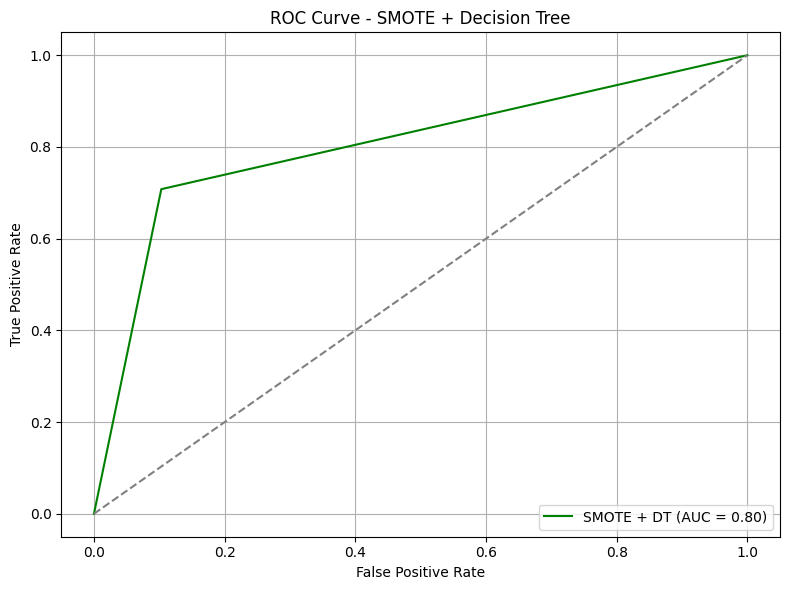


=== CLASS DISTRIBUTION AFTER SMOTE ===
BAD
0    3644
1    3644
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Step 1: Define SMOTE + Decision Tree pipeline
smote_dt_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Step 2: Fit the pipeline
smote_dt_pipeline.fit(X_train, y_train)

# Step 3: Predictions
y_train_pred = smote_dt_pipeline.predict(X_train)
y_test_pred = smote_dt_pipeline.predict(X_test)

y_train_proba = smote_dt_pipeline.predict_proba(X_train)[:, 1]
y_test_proba = smote_dt_pipeline.predict_proba(X_test)[:, 1]

# Step 4: ROC AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Step 5: Evaluation
print("\n===== DECISION TREE + SMOTE =====")

print("\n--- TRAINING SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

print("\n--- TEST SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# Step 6: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SMOTE + DT (AUC = {auc_test:.2f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SMOTE + Decision Tree")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Check SMOTE distribution
X_resampled, y_resampled = smote_dt_pipeline.named_steps['smote'].fit_resample(X_train, y_train)
print("\n=== CLASS DISTRIBUTION AFTER SMOTE ===")
print(pd.Series(y_resampled).value_counts())

Decision Tree with RUS


===== DECISION TREE + RUS =====

--- TRAINING SET ---
Confusion Matrix:
 [[3080  564]
 [   0  904]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92      3644
           1       0.62      1.00      0.76       904

    accuracy                           0.88      4548
   macro avg       0.81      0.92      0.84      4548
weighted avg       0.92      0.88      0.89      4548

Train ROC AUC: 0.9226

--- TEST SET ---
Confusion Matrix:
 [[725 187]
 [ 42 184]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.79      0.86       912
           1       0.50      0.81      0.62       226

    accuracy                           0.80      1138
   macro avg       0.72      0.80      0.74      1138
weighted avg       0.86      0.80      0.81      1138

Test ROC AUC: 0.8046


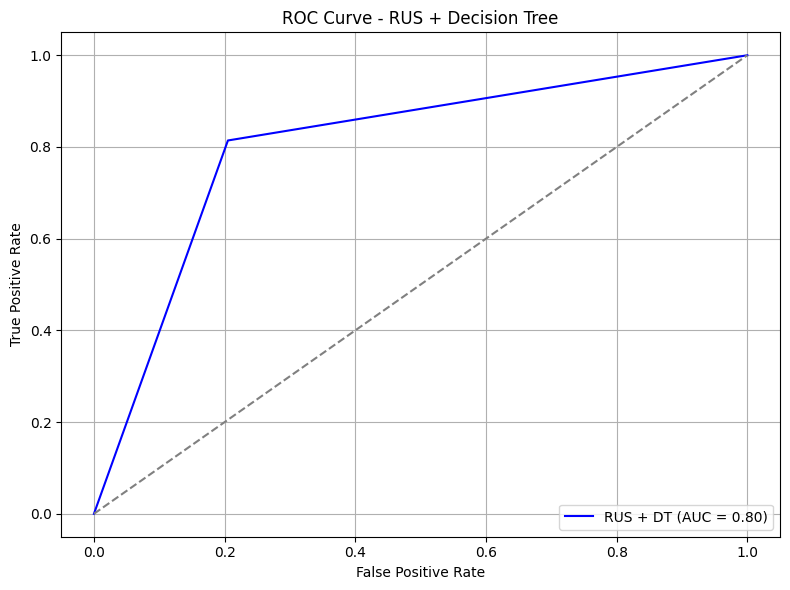


=== CLASS DISTRIBUTION AFTER RUS ===
BAD
0    904
1    904
Name: count, dtype: int64


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Step 1: Define RUS + Decision Tree pipeline
rus_dt_pipeline = Pipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Step 2: Fit the pipeline
rus_dt_pipeline.fit(X_train, y_train)

# Step 3: Predictions
y_train_pred = rus_dt_pipeline.predict(X_train)
y_test_pred = rus_dt_pipeline.predict(X_test)

y_train_proba = rus_dt_pipeline.predict_proba(X_train)[:, 1]
y_test_proba = rus_dt_pipeline.predict_proba(X_test)[:, 1]

# Step 4: ROC AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Step 5: Evaluation
print("\n===== DECISION TREE + RUS =====")

print("\n--- TRAINING SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

print("\n--- TEST SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# Step 6: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'RUS + DT (AUC = {auc_test:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RUS + Decision Tree")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Check RUS distribution
X_resampled, y_resampled = rus_dt_pipeline.named_steps['rus'].fit_resample(X_train, y_train)
print("\n=== CLASS DISTRIBUTION AFTER RUS ===")
print(pd.Series(y_resampled).value_counts())

Hyperparameter Tuning + SMOTE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Define pipeline
smote_dt_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Define hyperparameter grid
param_grid_dt = {
    'dt__max_depth': [3, 5, 10, None],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 3, 5],
    'dt__max_features': [None, 'sqrt', 'log2'],
    'dt__criterion': ['gini', 'entropy'],
    'dt__class_weight': ['balanced']
}


# Grid search
grid_smote_dt = GridSearchCV(
    smote_dt_pipeline,
    param_grid=param_grid_dt,
    scoring='recall',  # Or 'roc_auc'
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit
grid_smote_dt.fit(X_train, y_train)

# Evaluate best model
best_dt_smote = grid_smote_dt.best_estimator_
y_pred = best_dt_smote.predict(X_test)
y_proba = best_dt_smote.predict_proba(X_test)[:, 1]

print("\n===== Decision Tree + SMOTE + Tuning =====")
print("Best Parameters:", grid_smote_dt.best_params_)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SMOTE + Tuned DT (AUC = {roc_auc_score(y_test, y_proba):.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SMOTE + Decision Tree")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: check class balance
X_res, y_res = best_dt_smote.named_steps['smote'].fit_resample(X_train, y_train)
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_res).value_counts())


Hyperparameter Tuning + RUS

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Define pipeline
rus_dt_pipeline = Pipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Grid search
grid_rus_dt = GridSearchCV(
    rus_dt_pipeline,
    param_grid=param_grid_dt,
    scoring='recall',  # Or 'roc_auc'
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit
grid_rus_dt.fit(X_train, y_train)

# Evaluate best model
best_dt_rus = grid_rus_dt.best_estimator_
y_pred = best_dt_rus.predict(X_test)
y_proba = best_dt_rus.predict_proba(X_test)[:, 1]

print("\n===== Decision Tree + RUS + Tuning =====")
print("Best Parameters:", grid_rus_dt.best_params_)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'RUS + Tuned DT (AUC = {roc_auc_score(y_test, y_proba):.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RUS + Decision Tree")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: check class balance
X_res, y_res = best_dt_rus.named_steps['rus'].fit_resample(X_train, y_train)
print("\nClass Distribution After RUS:")
print(pd.Series(y_res).value_counts())


## Random Forrest (Model After Log Transform)



===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3644    0]
 [   0  904]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3644
           1       1.00      1.00      1.00       904

    accuracy                           1.00      4548
   macro avg       1.00      1.00      1.00      4548
weighted avg       1.00      1.00      1.00      4548

Train ROC AUC Score: 1.0000

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[889  23]
 [ 63 163]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       912
           1       0.88      0.72      0.79       226

    accuracy                           0.92      1138
   macro avg       0.91      0.85      0.87      1138
weighted avg       0.92      0.92      0.92      1138

Test ROC AUC Score: 0.9724


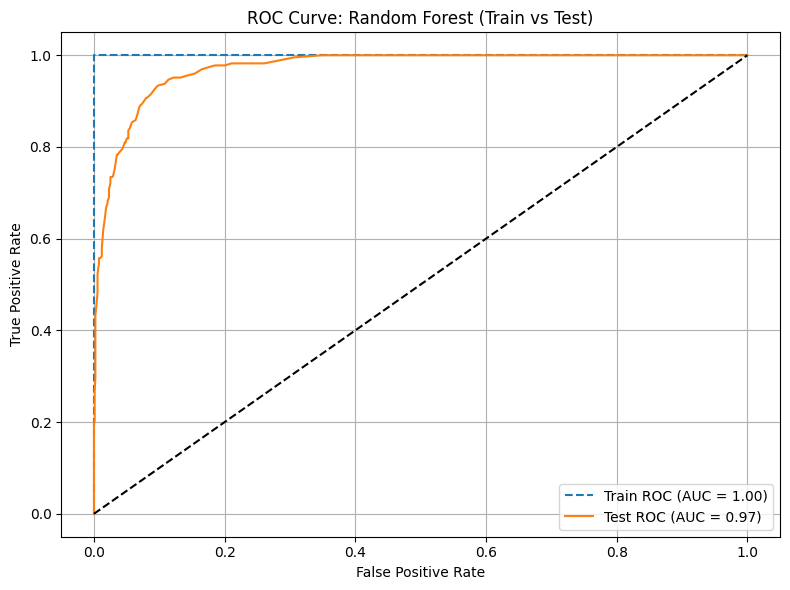

In [ ]:
# 1. Initialize and train the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# 2. Predictions: train and test
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 3. AUC Scores
auc_train_rf = roc_auc_score(y_train, y_train_proba_rf)
auc_test_rf = roc_auc_score(y_test, y_test_proba_rf)

# 4. Train Evaluation
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_rf))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_rf))
print(f"Train ROC AUC Score: {auc_train_rf:.4f}")

# 5. Test Evaluation
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_rf))
print(f"Test ROC AUC Score: {auc_test_rf:.4f}")

# 6. ROC Curve: Train vs Test
fpr_train_rf, tpr_train_rf, _ = roc_curve(y_train, y_train_proba_rf)
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, y_test_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train_rf, tpr_train_rf, label=f"Train ROC (AUC = {auc_train_rf:.2f})", linestyle='--')
plt.plot(fpr_test_rf, tpr_test_rf, label=f"Test ROC (AUC = {auc_test_rf:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Random Forest (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Cross Validation

In [ ]:
#Set up Stratified K-Fold Cross-Validation on Training Set
cv_rf_scores=cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-Validation ROC_AUC Scores: {cv_rf_scores}")
print(f"Mean ROC_AUC Score: {np.mean(cv_rf_scores):.4f}")
print(f"Standard Deviation of ROC_AUC: {np.std(cv_rf_scores):.4f}")

Cross-Validation ROC_AUC Scores: [0.97089802 0.96004566 0.97852359 0.9721309  0.9585346  0.97598418
 0.97960693 0.97473131 0.9593254  0.96987179]
Mean ROC_AUC Score: 0.9700
Standard Deviation of ROC_AUC: 0.0076


Hyperparameter

In [ ]:
# Define param grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 1500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced'],
}

# Set up the grid search
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='recall',  # or 'recall', 'f1', etc. depending on your goal
    cv=10,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# 3. Predictions
y_train_pred_rf = best_rf_model.predict(X_train)
y_test_pred_rf = best_rf_model.predict(X_test)

y_train_proba_rf = best_rf_model.predict_proba(X_train)[:, 1]
y_test_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

# 4. AUC Scores
auc_train_rf = roc_auc_score(y_train, y_train_proba_rf)
auc_test_rf = roc_auc_score(y_test, y_test_proba_rf)

# 5. Train Evaluation
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_rf))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_rf))
print(f"Train ROC AUC Score: {auc_train_rf:.4f}")

# 6. Test Evaluation
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_rf))
print(f"Test ROC AUC Score: {auc_test_rf:.4f}")

# 7. ROC Curve: Train vs Test
fpr_train_rf, tpr_train_rf, _ = roc_curve(y_train, y_train_proba_rf)
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, y_test_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train_rf, tpr_train_rf, label=f"Train ROC (AUC = {auc_train_rf:.2f})", linestyle='--')
plt.plot(fpr_test_rf, tpr_test_rf, label=f"Test ROC (AUC = {auc_test_rf:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Random Forest (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#Expected Profit
TN_rf, FP_rf, FN_rf, TP_rf = confusion_matrix(y_test, y_test_pred_rf).ravel()
print(f"True Negatives (TN): {TN_rf}")
print(f"False Positives (FP): {FP_rf}")
print(f"False Negatives (FN): {FN_rf}")
print(f"True Positives (TP): {TP_rf}")
exp_profit_rf=TN_rf-FN_rf-FP_rf
print(f"Expected Profit Random Forest: {exp_profit_rf}")

Fitting 10 folds for each of 162 candidates, totalling 1620 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

## XG Boost (Model After Log Transform)

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3643    1]
 [   0  904]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3644
           1       1.00      1.00      1.00       904

    accuracy                           1.00      4548
   macro avg       1.00      1.00      1.00      4548
weighted avg       1.00      1.00      1.00      4548

Train ROC AUC Score: 1.0000

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[868  44]
 [ 36 190]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       912
           1       0.81      0.84      0.83       226

    accuracy                           0.93      1138
   macro avg       0.89      0.90      0.89      1138
weighted avg       0.93      0.93      0.93      1138

Test ROC AUC Score: 0.9719


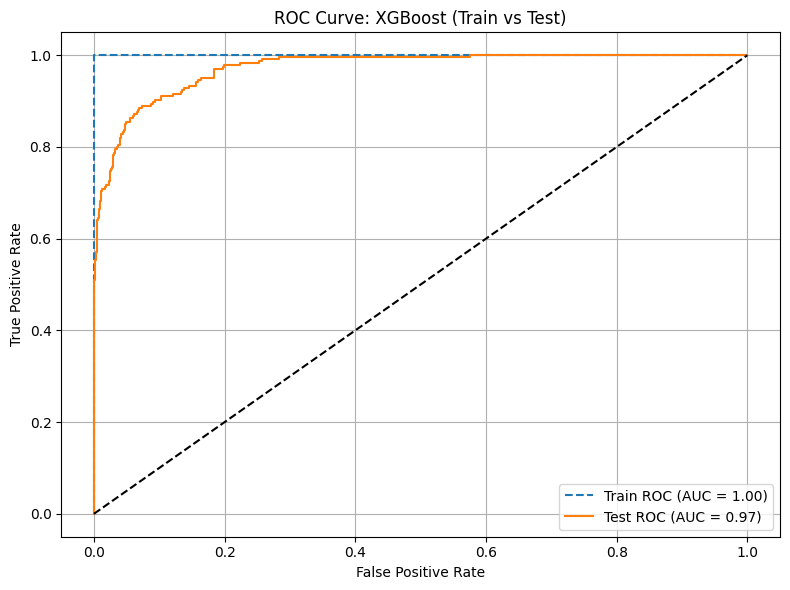

In [ ]:
from xgboost import XGBClassifier
# 1. Train the model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 2. Predictions: train & test
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

y_train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 3. AUC scores
auc_train_xgb = roc_auc_score(y_train, y_train_proba_xgb)
auc_test_xgb = roc_auc_score(y_test, y_test_proba_xgb)

# 4. Evaluation: Train
print("===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_xgb))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_xgb))
print(f"Train ROC AUC Score: {auc_train_xgb:.4f}")

# 5. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_xgb))
print(f"Test ROC AUC Score: {auc_test_xgb:.4f}")

# 6. Plot ROC Curve (Train vs Test)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_xgb)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train_xgb:.2f})", linestyle='--')
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test_xgb:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: XGBoost (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Cross Validation

In [ ]:
#Set up Stratified K-Fold Cross-Validation on Training Set
cv_xgb_scores=cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-Validation ROC_AUC Scores: {cv_xgb_scores}")
print(f"Mean ROC_AUC Score: {np.mean(cv_xgb_scores):.4f}")
print(f"Standard Deviation of ROC_AUC: {np.std(cv_xgb_scores):.4f}")

Cross-Validation ROC_AUC Scores: [0.96961948 0.955586   0.9729376  0.97622527 0.95565149 0.96654993
 0.98043715 0.97461055 0.96770452 0.95906593]
Mean ROC_AUC Score: 0.9678
Standard Deviation of ROC_AUC: 0.0083


Hyperparameter

Fitting 10 folds for each of 216 candidates, totalling 2160 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 100, 'scale_pos_weight': 10, 'subsample': 1.0}
Best CV AUC: 0.8938583638583639

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3124  520]
 [  31  873]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92      3644
           1       0.63      0.97      0.76       904

    accuracy                           0.88      4548
   macro avg       0.81      0.91      0.84      4548
weighted avg       0.92      0.88      0.89      4548

Train ROC AUC: 0.9741

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[764 148]
 [ 28 198]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.84      0.90       912
           1       0.57      0.88      0.69       226

    accuracy                           0

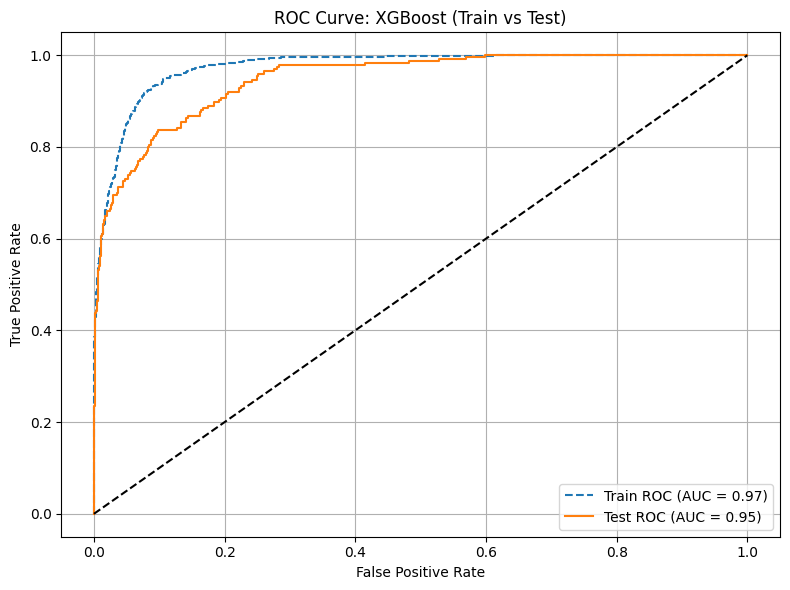

True Negatives (TN): 764
False Positives (FP): 148
False Negatives (FN): 28
True Positives (TP): 198
Expected Profit Decision Tree: 588


In [ ]:
# 1. Define parameter grid for tuning
param_grid = {'n_estimators':[100,200, 1500],'max_depth':[4,6,8], 'scale_pos_weight':[1,4.16,10], 'min_child_weight':[3,5],
                       'learning_rate':[0.1,0.2], 'subsample': [0.8, 1.0]}

# 2. Initialize base model with imbalance handling
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42
)

# 3. GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 4. Best estimator
best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

# 5. Predict on train & test
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

y_train_proba = best_xgb.predict_proba(X_train)[:, 1]
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

# 6. AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 7. Train Evaluation
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

# 8. Test Evaluation
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# 9. ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.2f})", linestyle='--')
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: XGBoost (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#Expected Profit
TN_xgb, FP_xgb, FN_xgb, TP_xgb = confusion_matrix(y_test, y_test_pred).ravel()
print(f"True Negatives (TN): {TN_xgb}")
print(f"False Positives (FP): {FP_xgb}")
print(f"False Negatives (FN): {FN_xgb}")
print(f"True Positives (TP): {TP_xgb}")
exp_profit_xgb=TN_xgb-FN_xgb-FP_xgb
print(f"Expected Profit Decision Tree: {exp_profit_xgb}")

### Overfitting Method using SHAP (Not Used)

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model, X_train)
# Calculates the SHAP values - It takes some time
shap_values = explainer(X_train)
shap_values = pd.DataFrame(shap_values.values, columns=X_train.columns)
importance = {col:shap_values[col].abs().mean() for col in shap_values.columns}
importance = pd.DataFrame({'mean_sv':importance.values()}, index=importance.keys())
# normalise the importances
importance['mean_sv'] = importance['mean_sv']/importance['mean_sv'].sum()
# and sort them
importance = importance.sort_values(by='mean_sv', ascending=False)

 95%|=================== | 4333/4548 [00:20<00:00]       

<ipython-input-56-406fb64126f5>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= importance.mean_sv, y=importance.index, palette=feature_colors)


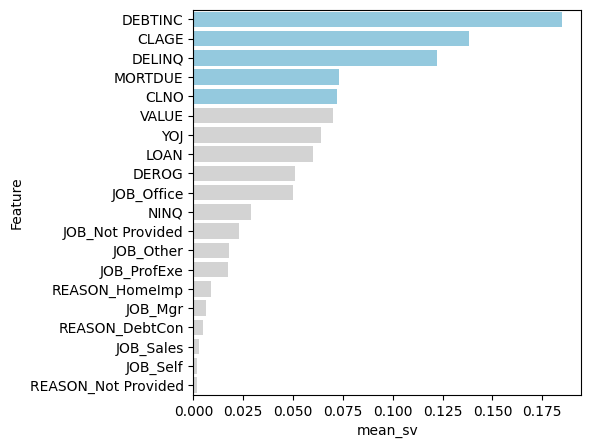

In [ ]:
# Percentage of features to retain
feature_percentage = 0.6
# Now calculate the cumulative sum for cutoff
importance['cumulative'] = importance['mean_sv'].cumsum()
important_features = importance[importance.cumulative <= feature_percentage].index
feature_colors = ['skyblue' if feature in important_features else 'lightgrey' for feature in importance.index]

# Plot the importances
plt.figure(figsize = (5, 5))
ax = sns.barplot(x= importance.mean_sv, y=importance.index, palette=feature_colors)
ax.set_ylabel('Feature');

In [ ]:
# Create a reduced data set
X_train_red = X_train[important_features]
X_test_red = X_test[important_features]

In [ ]:
X_train_red

,DEBTINC,CLAGE,DELINQ,MORTDUE,CLNO
2966,0.550392,0.519190,0.000000,0.188424,0.890909
4477,0.545361,0.197368,0.000000,0.145534,0.236364
4754,0.541774,0.194537,0.154151,0.240330,0.436364
5238,0.351672,0.290501,0.000000,0.232330,0.327273
2734,0.639006,0.184774,0.000000,0.089899,0.272727
...,...,...,...,...,...
5192,0.636068,0.224921,0.000000,0.141270,0.545455
2602,0.541774,0.223318,0.154151,0.122805,0.272727
4442,0.544466,0.246839,0.000000,0.139407,0.381818
912,0.575502,0.182686,0.154151,0.129303,0.327273


===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3533  111]
 [   0  904]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98      3644
           1       0.89      1.00      0.94       904

    accuracy                           0.98      4548
   macro avg       0.95      0.98      0.96      4548
weighted avg       0.98      0.98      0.98      4548

Train ROC AUC Score: 0.9988

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[838  74]
 [ 56 170]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       912
           1       0.70      0.75      0.72       226

    accuracy                           0.89      1138
   macro avg       0.82      0.84      0.83      1138
weighted avg       0.89      0.89      0.89      1138

Test ROC AUC Score: 0.9311


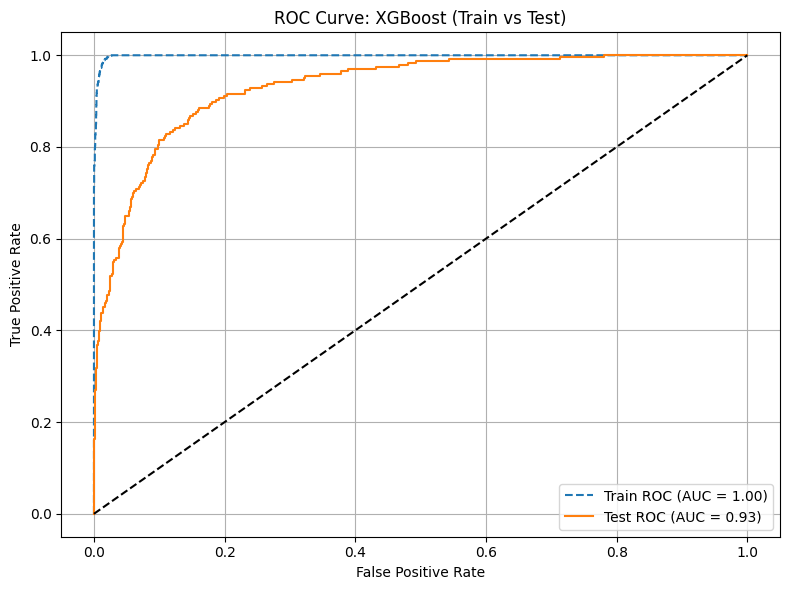

In [ ]:
xgb_model.fit(X_train_red, y_train)

# 2. Predictions: train & test
y_train_pred_xgb = xgb_model.predict(X_train_red)
y_test_pred_xgb = xgb_model.predict(X_test_red)

y_train_proba_xgb = xgb_model.predict_proba(X_train_red)[:, 1]
y_test_proba_xgb = xgb_model.predict_proba(X_test_red)[:, 1]

# 3. AUC scores
auc_train_xgb = roc_auc_score(y_train, y_train_proba_xgb)
auc_test_xgb = roc_auc_score(y_test, y_test_proba_xgb)

# 4. Evaluation: Train
print("===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_xgb))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_xgb))
print(f"Train ROC AUC Score: {auc_train_xgb:.4f}")

# 5. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_xgb))
print(f"Test ROC AUC Score: {auc_test_xgb:.4f}")

# 6. Plot ROC Curve (Train vs Test)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba_xgb)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train_xgb:.2f})", linestyle='--')
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test_xgb:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: XGBoost (Train vs Test)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Neural Network MLP (Model After Log Transform)

Base Model

Confusion Matrix:
[[1290   77]
 [  81  258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1367
           1       0.77      0.76      0.77       339

    accuracy                           0.91      1706
   macro avg       0.86      0.85      0.85      1706
weighted avg       0.91      0.91      0.91      1706


ROC AUC Score: 0.9360


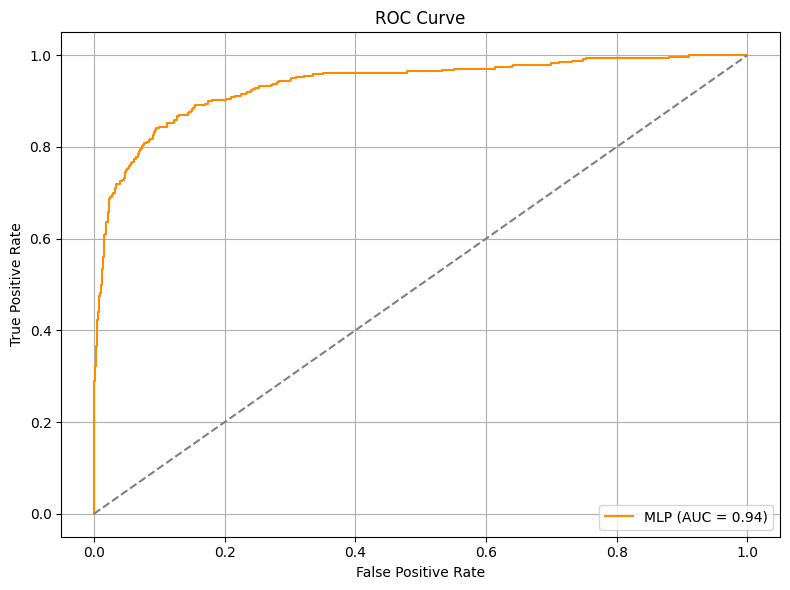

In [ ]:
# Initialize the MLP model
MLP_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # You can tune this
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# Fit the model
MLP_model.fit(X_train, y_train)

# Predict labels
y_pred = MLP_model.predict(X_test)

# Predict probabilities (for ROC AUC)
y_proba = MLP_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC AUC Score
auc = roc_auc_score(y_test, y_proba)
print(f"\nROC AUC Score: {auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'MLP (AUC = {auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Cross Validation

In [ ]:
#Set up Stratified K-Fold Cross-Validation on Training Set
cv_mlp_scores=cross_val_score(MLP_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-Validation ROC_AUC Scores: {cv_mlp_scores}")
print(f"Mean ROC_AUC Score: {np.mean(cv_mlp_scores):.4f}")
print(f"Standard Deviation of ROC_AUC: {np.std(cv_mlp_scores):.4f}")

Cross-Validation ROC_AUC Scores: [0.91829689 0.94754176 0.94337526 0.92714575 0.93615333 0.93833578
 0.90881314 0.9368279  0.87020356 0.90039308]
Mean ROC_AUC Score: 0.9227
Standard Deviation of ROC_AUC: 0.0227


Hyperparameter Tuning

In [ ]:
# 1. Define hyperparameter grid
param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 penalty (regularization)
    'learning_rate': ['constant', 'adaptive'],
}

# 2. GridSearchCV setup
mlp_base = MLPClassifier(
    max_iter=1000,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=mlp_base,
    param_grid=param_grid,
    scoring='recall',  # You can also use 'recall' or 'f1' based on your business goal
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_mlp_model = grid_search.best_estimator_

print("\nBest Parameters Found:", grid_search.best_params_)

# 3. Predictions
y_train_pred = best_mlp_model.predict(X_train)
y_test_pred = best_mlp_model.predict(X_test)

y_train_proba = best_mlp_model.predict_proba(X_train)[:, 1]
y_test_proba = best_mlp_model.predict_proba(X_test)[:, 1]

# 4. AUC Scores
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 5. Evaluation: Train
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 6. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 7. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'MLP (AUC = {auc_test:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#Expected Profit
TN_mlp, FP_mlp, FN_mlp, TP_mlp = confusion_matrix(y_test, y_test_pred).ravel()
print(f"True Negatives (TN): {TN_mlp}")
print(f"False Positives (FP): {FP_mlp}")
print(f"False Negatives (FN): {FN_mlp}")
print(f"True Positives (TP): {TP_mlp}")
exp_profit_mlp=TN_mlp-FN_mlp-FP_mlp
print(f"Expected Profit MLP Classifier: {exp_profit_mlp}")

Fitting 10 folds for each of 96 candidates, totalling 960 fits


KeyboardInterrupt: 

MLP with SMOTE

In [ ]:
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE

# Step 1: Define SMOTE + MLP pipeline
smote_mlp_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42))
])

# Step 2: Fit the pipeline
smote_mlp_pipeline.fit(X_train, y_train)

# Step 3: Predictions
y_train_pred = smote_mlp_pipeline.predict(X_train)
y_test_pred = smote_mlp_pipeline.predict(X_test)

y_train_proba = smote_mlp_pipeline.predict_proba(X_train)[:, 1]
y_test_proba = smote_mlp_pipeline.predict_proba(X_test)[:, 1]

# Step 4: ROC AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Step 5: Evaluation
print("\n===== MLP + SMOTE =====")

print("\n--- TRAINING SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

print("\n--- TEST SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# Step 6: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SMOTE + MLP (AUC = {auc_test:.2f})', color='darkgreen')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SMOTE + MLP")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Check SMOTE distribution
X_resampled, y_resampled = smote_mlp_pipeline.named_steps['smote'].fit_resample(X_train, y_train)
print("\n=== CLASS DISTRIBUTION AFTER SMOTE ===")
print(pd.Series(y_resampled).value_counts())


MLP with RUS

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Step 1: Define RUS + MLP pipeline
rus_mlp_pipeline = Pipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42))
])

# Step 2: Fit the pipeline
rus_mlp_pipeline.fit(X_train, y_train)

# Step 3: Predictions
y_train_pred = rus_mlp_pipeline.predict(X_train)
y_test_pred = rus_mlp_pipeline.predict(X_test)

y_train_proba = rus_mlp_pipeline.predict_proba(X_train)[:, 1]
y_test_proba = rus_mlp_pipeline.predict_proba(X_test)[:, 1]

# Step 4: ROC AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Step 5: Evaluation
print("\n===== MLP + RUS =====")

print("\n--- TRAINING SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC: {auc_train:.4f}")

print("\n--- TEST SET ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC: {auc_test:.4f}")

# Step 6: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'RUS + MLP (AUC = {auc_test:.2f})', color='tomato')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RUS + MLP")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Check RUS distribution
X_resampled, y_resampled = rus_mlp_pipeline.named_steps['rus'].fit_resample(X_train, y_train)
print("\n=== CLASS DISTRIBUTION AFTER RUS ===")
print(pd.Series(y_resampled).value_counts())


Hyperparameter Tuning + SMOTE

In [ ]:
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Define pipeline
smote_mlp_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42))
])

# Define param grid
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(64,), (64, 32), (128, 64), (128, 64, 32)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__solver': ['adam', 'sgd'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate': ['constant', 'adaptive']
}


# GridSearchCV setup
grid_smote_mlp = GridSearchCV(
    smote_mlp_pipeline,
    param_grid=param_grid_mlp,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_smote_mlp.fit(X_train, y_train)

# Evaluate best model
best_mlp_smote = grid_smote_mlp.best_estimator_
y_pred = best_mlp_smote.predict(X_test)
y_proba = best_mlp_smote.predict_proba(X_test)[:, 1]

# Evaluation
print("\n===== MLP + SMOTE + GridSearchCV =====")
print("Best Parameters:", grid_smote_mlp.best_params_)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SMOTE + MLP (AUC = {roc_auc_score(y_test, y_proba):.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SMOTE + MLP")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Check class distribution after SMOTE
X_res, y_res = best_mlp_smote.named_steps['smote'].fit_resample(X_train, y_train)
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_res).value_counts())

Hyperparameter Tuning + RUS

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Define pipeline
rus_mlp_pipeline = Pipeline([
    ('rus', RandomUnderSampler(random_state=42)),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42))
])

# GridSearchCV setup
grid_rus_mlp = GridSearchCV(
    rus_mlp_pipeline,
    param_grid=param_grid_mlp,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_rus_mlp.fit(X_train, y_train)

# Evaluate best model
best_mlp_rus = grid_rus_mlp.best_estimator_
y_pred = best_mlp_rus.predict(X_test)
y_proba = best_mlp_rus.predict_proba(X_test)[:, 1]

# Evaluation
print("\n===== MLP + RUS + GridSearchCV =====")
print("Best Parameters:", grid_rus_mlp.best_params_)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Test ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'RUS + MLP (AUC = {roc_auc_score(y_test, y_proba):.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RUS + MLP")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Check class distribution after RUS
X_res, y_res = best_mlp_rus.named_steps['rus'].fit_resample(X_train, y_train)
print("\nClass Distribution After RUS:")
print(pd.Series(y_res).value_counts())

## LightGBM (Model After Log Transform)

Base Model

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 791, number of negative: 3189
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000589 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1438
[LightGBM] [Info] Number of data points in the train set: 3980, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3130   59]
 [   0  791]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      3189
           1       0.93      1.00      0.96       791

    accuracy                           0.99      3980
   macro avg       0.97      0.99      0.9

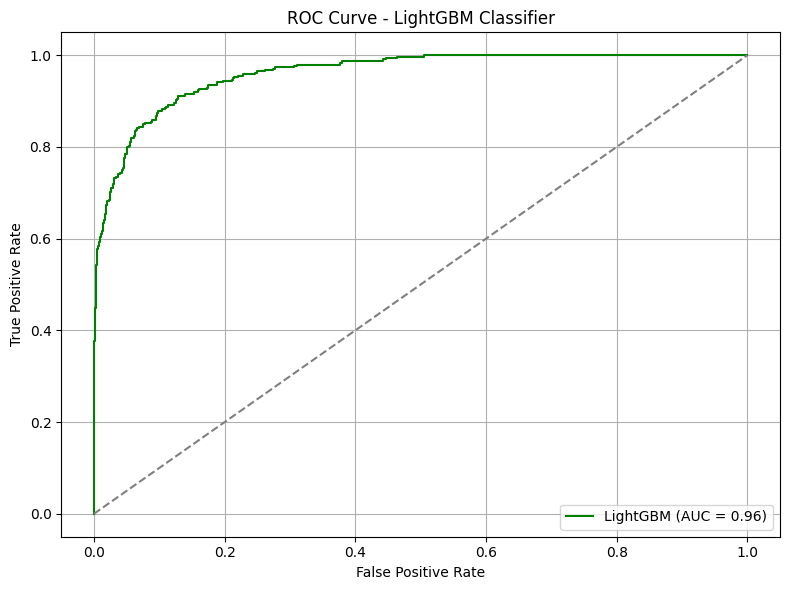

In [ ]:
from lightgbm import LGBMClassifier

# 1. Initialize and train the LightGBM model
lgbm_model = LGBMClassifier(
    class_weight='balanced',       # Handle imbalanced classes
    random_state=42,
    n_estimators=100               # Reasonable starting point
)

lgbm_model.fit(X_train, y_train)

# 2. Predictions
y_train_pred = lgbm_model.predict(X_train)
y_test_pred = lgbm_model.predict(X_test)

y_train_proba = lgbm_model.predict_proba(X_train)[:, 1]
y_test_proba = lgbm_model.predict_proba(X_test)[:, 1]

# 3. AUC Scores
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 4. Evaluation: Train
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 5. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 6. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc_test:.2f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


LightGBM Model

In [ ]:
#Set up Stratified K-Fold Cross-Validation on Training Set
cv_lgbm_scores=cross_val_score(lgbm_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-Validation ROC_AUC Scores: {cv_lgbm_scores}")
print(f"Mean ROC_AUC Score: {np.mean(cv_lgbm_scores):.4f}")
print(f"Standard Deviation of ROC_AUC: {np.std(cv_lgbm_scores):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 712, number of negative: 2870
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000741 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1437
[LightGBM] [Info] Number of data points in the train set: 3582, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 712, number of negative: 2870
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=t

Hyperparameter tuning

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 904, number of negative: 3644
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001049 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1433
[LightGBM] [Info] Number of data points in the train set: 4548, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Best Parameters Found: {'class_weight': 'balanced', 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 15, 'subsample': 0.8}

===== TRAINING SE

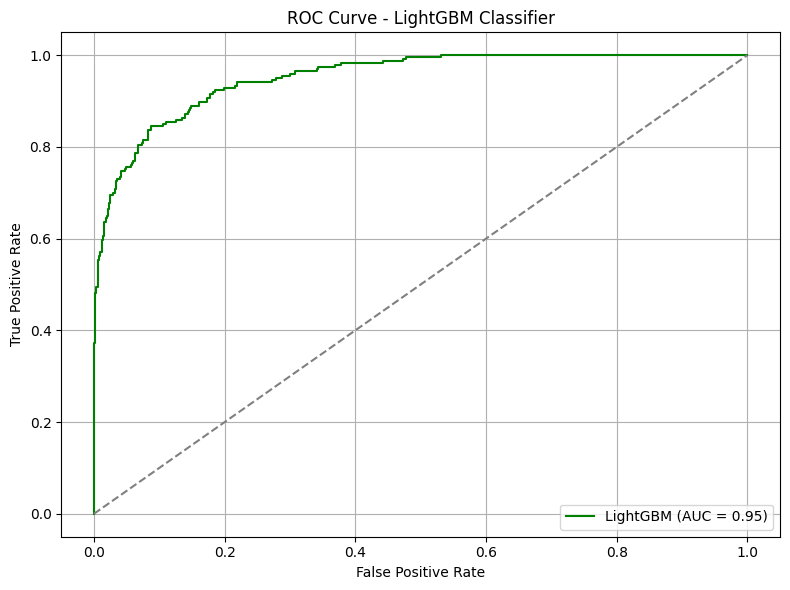

In [ ]:
# 1. Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63],  # num_leaves should be <= 2^max_depth
    'learning_rate': [0.01, 0.1],
    'min_child_samples': [10, 20],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'class_weight': ['balanced']
}

# 2. GridSearchCV setup
lgbm_base = LGBMClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid,
    scoring='recall',  # change to 'recall' if that’s your focus
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_lgbm_model = grid_search.best_estimator_

print("\nBest Parameters Found:", grid_search.best_params_)

# 3. Predictions
y_train_pred = best_lgbm_model.predict(X_train)
y_test_pred = best_lgbm_model.predict(X_test)

y_train_proba = best_lgbm_model.predict_proba(X_train)[:, 1]
y_test_proba = best_lgbm_model.predict_proba(X_test)[:, 1]

# 4. AUC Scores
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 5. Evaluation: Train
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 6. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 7. ROC Curve: Test Set
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc_test:.2f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#Expected Profit
TN_lgbm, FP_lgbm, FN_lgbm, TP_lgbm = confusion_matrix(y_test, y_test_pred_dt).ravel()
print(f"True Negatives (TN): {TN_lgbm}")
print(f"False Positives (FP): {FP_lgbm}")
print(f"False Negatives (FN): {FN_lgbm}")
print(f"True Positives (TP): {TP_lgbm}")
exp_profit_lgbm=TN_lgbm-FN_lgbm-FP_lgbm
print(f"Expected Profit Light GBM : {exp_profit_lgbm}")


## CatBoost (Model After Log Transform)

Base Model


===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3105   84]
 [  19  772]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3189
           1       0.90      0.98      0.94       791

    accuracy                           0.97      3980
   macro avg       0.95      0.97      0.96      3980
weighted avg       0.98      0.97      0.97      3980

Train ROC AUC Score: 0.9977

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[1287   80]
 [  64  275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95      1367
           1       0.77      0.81      0.79       339

    accuracy                           0.92      1706
   macro avg       0.86      0.88      0.87      1706
weighted avg       0.92      0.92      0.92      1706

Test ROC AUC Score: 0.9651


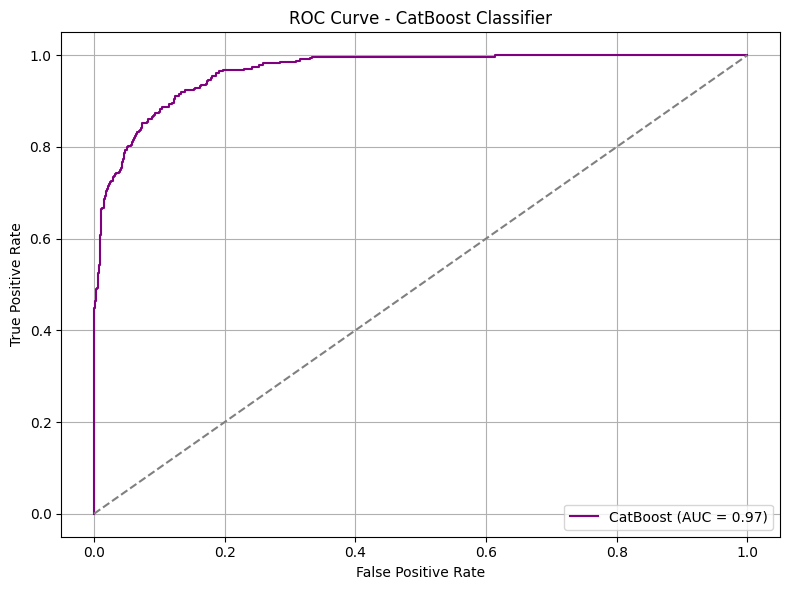

In [ ]:
from catboost import CatBoostClassifier

# 1. Initialize and train the CatBoost model
cat_model = CatBoostClassifier(
    verbose=0,                    # Suppress CatBoost training output
    class_weights=[1, 3],         # Adjust if your positive class is underrepresented
    random_state=42
)

cat_model.fit(X_train, y_train)

# 2. Predictions
y_train_pred = cat_model.predict(X_train)
y_test_pred = cat_model.predict(X_test)

y_train_proba = cat_model.predict_proba(X_train)[:, 1]
y_test_proba = cat_model.predict_proba(X_test)[:, 1]

# 3. AUC Scores
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 4. Evaluation: Train
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 5. Evaluation: Test
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 6. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {auc_test:.2f})', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#Expected Profit
TN_cat, FP_cat, FN_cat, TP_cat = confusion_matrix(y_test, y_test_pred).ravel()
print(f"True Negatives (TN): {TN_cat}")
print(f"False Positives (FP): {FP_cat}")
print(f"False Negatives (FN): {FN_cat}")
print(f"True Positives (TP): {TP_cat}")
exp_profit_cat=TN_cat-FN_cat-FP_cat
print(f"Expected Profit Light GBM : {exp_profit_cat}")


Cross Validation

In [ ]:
#Set up Stratified K-Fold Cross-Validation on Training Set
cv_cat_scores=cross_val_score(cat_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-Validation ROC_AUC Scores: {cv_cat_scores}")
print(f"Mean ROC_AUC Score: {np.mean(cv_cat_scores):.4f}")
print(f"Standard Deviation of ROC_AUC: {np.std(cv_cat_scores):.4f}")

Cross-Validation ROC_AUC Scores: [0.97861196 0.97162811 0.96246181 0.96869172 0.95071624 0.95103369
 0.96341415 0.97575493 0.95317646 0.95318396]
Mean ROC_AUC Score: 0.9629
Standard Deviation of ROC_AUC: 0.0100


Hyperparameter Tuning

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best Parameters Found: {'bootstrap_type': 'Bernoulli', 'class_weights': [1, 5], 'depth': 6, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.1}

===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3328  316]
 [  55  849]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.95      3644
           1       0.73      0.94      0.82       904

    accuracy                           0.92      4548
   macro avg       0.86      0.93      0.88      4548
weighted avg       0.93      0.92      0.92      4548

Train ROC AUC Score: 0.9782

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[815  97]
 [ 33 193]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.93       912
           1       0.67      0.85      0.75       226

    accuracy                           0.89      1138
   m

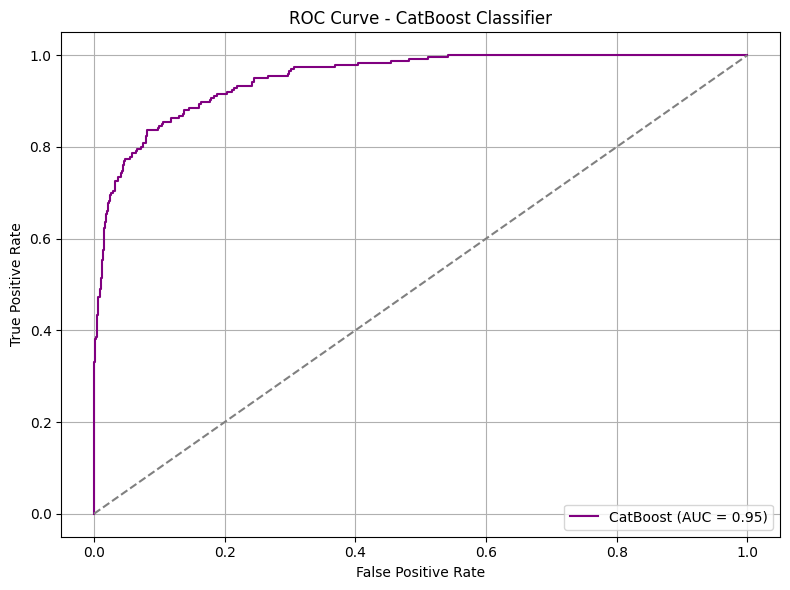

In [ ]:
# 1. Define parameter grid
param_grid = {
    'iterations': [100, 300],
    'learning_rate': [0.01, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5],
    'class_weights': [[1, 3], [1, 5]],  # For imbalanced classes
    'bootstrap_type': ['Bayesian', 'Bernoulli'],
}

# 2. Set up base model
cb_base = CatBoostClassifier(
    verbose=0,  # Suppress CatBoost training logs
    random_state=42
)

# 3. GridSearchCV setup
grid_search = GridSearchCV(
    estimator=cb_base,
    param_grid=param_grid,
    scoring='recall',  # You can change this to 'recall'
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_cb_model = grid_search.best_estimator_

print("\nBest Parameters Found:", grid_search.best_params_)

# 4. Predictions
y_train_pred = best_cb_model.predict(X_train)
y_test_pred = best_cb_model.predict(X_test)

y_train_proba = best_cb_model.predict_proba(X_train)[:, 1]
y_test_proba = best_cb_model.predict_proba(X_test)[:, 1]

# 5. AUC Scores
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 6. Train Evaluation
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 7. Test Evaluation
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 8. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {auc_test:.2f})', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## Stacked Ensemble (Model After Log Transform)

Base Model


===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3188    1]
 [  21  770]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      3189
           1       1.00      0.97      0.99       791

    accuracy                           0.99      3980
   macro avg       1.00      0.99      0.99      3980
weighted avg       0.99      0.99      0.99      3980

Train ROC AUC Score: 1.0000

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[1325   42]
 [  84  255]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      1367
           1       0.86      0.75      0.80       339

    accuracy                           0.93      1706
   macro avg       0.90      0.86      0.88      1706
weighted avg       0.92      0.93      0.92      1706

Test ROC AUC Score: 0.9606


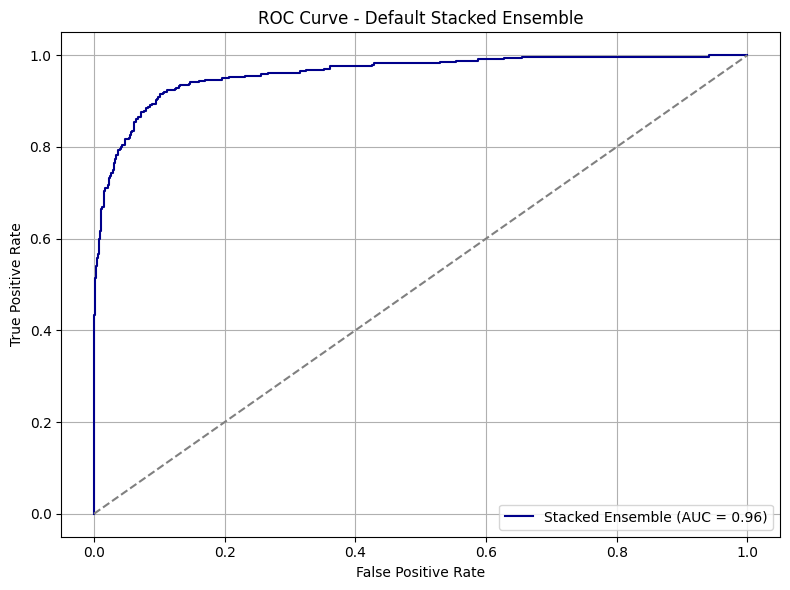

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 1. Define base models (with mostly default parameters)
base_learners = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('catboost', CatBoostClassifier(verbose=0, random_state=42))
]

# 2. Meta-learner
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# 3. Stacking Classifier
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=True
)

# 4. Train the stacked model
stack_model.fit(X_train, y_train)

# 5. Predict
y_train_pred = stack_model.predict(X_train)
y_test_pred = stack_model.predict(X_test)

y_train_proba = stack_model.predict_proba(X_train)[:, 1]
y_test_proba = stack_model.predict_proba(X_test)[:, 1]

# 6. AUC Scores
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 7. Train Evaluation
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 8. Test Evaluation
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 9. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Stacked Ensemble (AUC = {auc_test:.2f})', color='darkblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Default Stacked Ensemble")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Cross Validation

In [ ]:
#Set up Stratified K-Fold Cross-Validation on Training Set
cv_stack_scores=cross_val_score(stack_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-Validation ROC_AUC Scores: {cv_stack_scores}")
print(f"Mean ROC_AUC Score: {np.mean(cv_stack_scores):.4f}")
print(f"Standard Deviation of ROC_AUC: {np.std(cv_stack_scores):.4f}")

KeyboardInterrupt: 

Hyperparameter Tuning


===== TRAINING SET EVALUATION =====
Confusion Matrix:
 [[3619   25]
 [   0  904]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      3644
           1       0.97      1.00      0.99       904

    accuracy                           0.99      4548
   macro avg       0.99      1.00      0.99      4548
weighted avg       0.99      0.99      0.99      4548

Train ROC AUC Score: 1.0000

===== TEST SET EVALUATION =====
Confusion Matrix:
 [[848  64]
 [ 17 209]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95       912
           1       0.77      0.92      0.84       226

    accuracy                           0.93      1138
   macro avg       0.87      0.93      0.90      1138
weighted avg       0.94      0.93      0.93      1138

Test ROC AUC Score: 0.9751


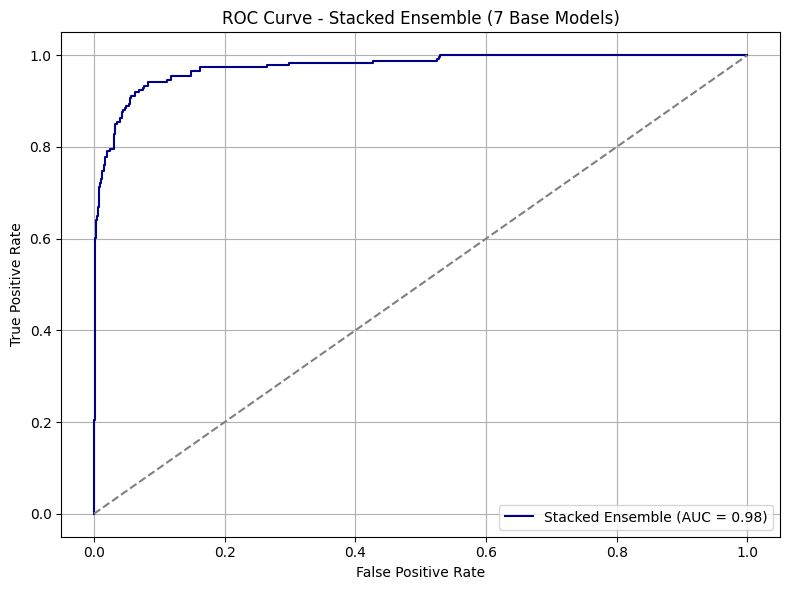

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# 1. Define all base learners
base_learners = [
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=3, random_state=42)),
    ('lgbm', LGBMClassifier(class_weight='balanced', random_state=42)),
    ('catboost', CatBoostClassifier(verbose=0, class_weights=[1, 3], random_state=42))
]

# 2. Meta-learner
meta_learner = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 3. Stacking Classifier setup
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=True
)

# 4. Train the model
stack_model.fit(X_train, y_train)

# 5. Predict
y_train_pred = stack_model.predict(X_train)
y_test_pred = stack_model.predict(X_test)

y_train_proba = stack_model.predict_proba(X_train)[:, 1]
y_test_proba = stack_model.predict_proba(X_test)[:, 1]

# 6. ROC AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# 7. Train evaluation
print("\n===== TRAINING SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print(f"Train ROC AUC Score: {auc_train:.4f}")

# 8. Test evaluation
print("\n===== TEST SET EVALUATION =====")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print(f"Test ROC AUC Score: {auc_test:.4f}")

# 9. Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Stacked Ensemble (AUC = {auc_test:.2f})', color='darkblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacked Ensemble (7 Base Models)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#Expected Profit
TN_sta, FP_sta, FN_sta, TP_sta = confusion_matrix(y_test, y_test_pred).ravel()
print(f"True Negatives (TN): {TN_sta}")
print(f"False Positives (FP): {FP_sta}")
print(f"False Negatives (FN): {FN_sta}")
print(f"True Positives (TP): {TP_sta}")
exp_profit_sta=TN_sta-FN_sta-FP_sta
print(f"Expected Profit Stacked Ensemble : {exp_profit_sta}")


## SHAP Values and Feature Importance

 95%|=================== | 3780/3980 [00:16<00:00]       

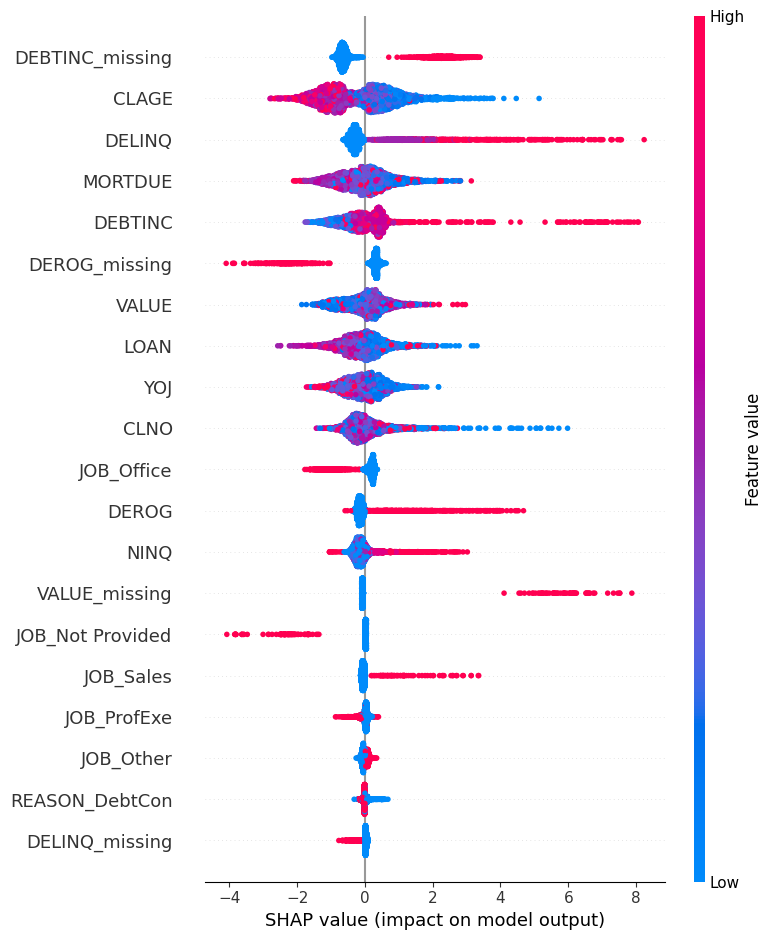

In [ ]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_model, X_train)
# Calculates the SHAP values - It takes some time
shap_values = explainer(X_train)

# Plotting the SHAP
shap.summary_plot(shap_values)

In [ ]:
## Feature Importance Table

import pandas as pd

# Assuming these are your trained models:
# logistic_model, decision_tree_model, rf_model, xgb_model, mlp_model
# And X_train is your original feature set (a DataFrame)

# 1. Logistic Regression (uses coef_)
logreg_importance = pd.Series(abs(model.coef_[0]), index=X_train.columns)
print(logreg_importance)

# 2. Decision Tree
tree_importance = pd.Series(dt_model.feature_importances_, index=X_train.columns)
print(tree_importance)

# 3. Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
print(rf_importance)

# 4. XGBoost
#xgb_importance = pd.Series(model.feature_importances_, index=X_train.columns)
#print(xgb_importance)

# 5. MLP (Neural Net) → use permutation importance
#from sklearn.inspection import permutation_importance
#result = permutation_importance(MLP_model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1)
#mlp_importance = pd.Series(result.importances_mean, index=X_train.columns)

# 6. Combine into one DataFrame
importance_df = pd.DataFrame({
    'Logistic Regression': logreg_importance,
    'Decision Tree': tree_importance,
    'Random Forest': rf_importance,
#   'XGBoost': xgb_importance,
#  'MLP': mlp_importance
})

# 7. Add average across models & sort
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values(by='Average', ascending=False)

# 8. Display top 10 features
importance_df.head(10)

LOAN                   1.517583
MORTDUE                0.829229
VALUE                  1.063350
YOJ                    0.794150
DEROG                  4.044831
DELINQ                 5.675225
CLAGE                  3.509217
NINQ                   2.208973
CLNO                   0.735546
DEBTINC                2.975185
REASON_DebtCon         0.356250
REASON_HomeImp         0.136318
REASON_Not Provided    0.008637
JOB_Mgr                0.069045
JOB_Not Provided       1.236715
JOB_Office             0.727069
JOB_Other              0.042656
JOB_ProfExe            0.106941
JOB_Sales              1.196638
JOB_Self               0.416544
dtype: float64
LOAN                   0.067197
MORTDUE                0.057886
VALUE                  0.066667
YOJ                    0.050786
DEROG                  0.023586
DELINQ                 0.038751
CLAGE                  0.090724
NINQ                   0.025730
CLNO                   0.061117
DEBTINC                0.461091
REASON_DebtCon         0.

,Logistic Regression,Decision Tree,Random Forest,Average
DELINQ,5.675225,0.038751,0.094091,1.936022
DEROG,4.044831,0.023586,0.042254,1.370224
CLAGE,3.509217,0.090724,0.110973,1.236971
DEBTINC,2.975185,0.461091,0.261267,1.232514
NINQ,2.208973,0.025730,0.041310,0.758671
LOAN,1.517583,0.067197,0.079616,0.554799
JOB_Not Provided,1.236715,0.001546,0.003219,0.413827
JOB_Sales,1.196638,0.011726,0.007507,0.405290
VALUE,1.063350,0.066667,0.080717,0.403578
MORTDUE,0.829229,0.057886,0.075326,0.320813
